# Analyse KPI Auto — Produit A vs Produit V

**Objectif** : Comparer les indicateurs techniques entre les produits **A** et **V**,
globalement et par garantie (RC, BDG, INC_VOL, DOM), puis analyser l'impact
des variables **Carburant**, **Âge conducteur** et **Marque**.

---
| Étape | Contenu |
|---|---|
| **1** | Chargement des données |
| **2** | Harmonisation (âge, carburant, marque) — *adapter ici vos vrais fichiers* |
| **3** | KPI globaux A vs V avec tableau coloré |
| **4** | KPI par garantie — tableau + graphique combiné (S/P / Fréquence / Coût moyen) |
| **5** | Analyse univariée (distribution · S/P · scatter Fréq×CM) |
| **6** | Analyse bivariée (courbes comparées A vs V avec zone d'écart) |

> Données simulées via `simulate_av.py` — **remplacer par vos vrais fichiers à l'étape 1**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)

# ── Thème seaborn ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'legend.framealpha': 0.85,
    'legend.fontsize'  : 9.5,
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
})

# ── Palette couleurs ──────────────────────────────────────────────────────────
COLOR_A    = '#1B4F72'   # bleu  — Produit A
COLOR_V    = '#E67E22'   # orange — Produit V
COLOR_OK   = '#1E8449'   # vert  — S/P < 70 %  (favorable)
COLOR_WARN = '#B7950B'   # doré  — S/P 70–100 %
COLOR_BAD  = '#C0392B'   # rouge — S/P > 100 % (défavorable)
COLOR_100  = '#E74C3C'   # ligne seuil 100 %

PAL_AV  = [COLOR_A, COLOR_V]
PAL_GAR = {'RC': '#2980B9', 'BDG': '#E74C3C', 'INC_VOL': '#8E44AD', 'DOM': '#27AE60'}

# ── Constantes métier ─────────────────────────────────────────────────────────
GARANTIES  = ['rc', 'bdg', 'incvol', 'dom']
GAR_LABEL  = {'rc': 'RC', 'bdg': 'BDG', 'incvol': 'INC_VOL', 'dom': 'DOM'}
GAR_ORDER  = [GAR_LABEL[g] for g in GARANTIES]

AGE_ORDER  = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+', 'Autres']
CARB_ORDER = ['DIESEL', 'ESSENCE', 'HYBRIDE', 'ELECTRIQUE', 'GPL', 'AUTRES']
MARQ_TOP   = ['RENAULT', 'PEUGEOT', 'CITROEN', 'VOLKSWAGEN',
               'BMW', 'MERCEDES', 'TOYOTA', 'FORD']
MARQ_ORDER = MARQ_TOP + ['AUTRES']

# ── Helpers mise en forme des tableaux (Styler) ───────────────────────────────
def _sp_color(val):
    '''Couleur cellule S/P : vert < 70 %, jaune 70-100 %, rouge > 100 %.'''
    try:
        v = float(str(val).replace('%', '').replace(',', '.').replace(' ', ''))
        v = v / 100 if v > 2 else v          # "75.3 %" → 0.753
        if   v < 0.70: return 'background:#D5F5E3; color:#1A5632'
        elif v < 1.00: return 'background:#FEF9E7; color:#7D6608'
        else:          return 'background:#FADBD8; color:#922B21; font-weight:bold'
    except Exception:
        return ''

def _ecart_color(val):
    '''Couleur écart V/A : vert si V < A (favorable), rouge si V > A.'''
    try:
        v = float(str(val).replace('%', '').replace('+', '').replace(' ', ''))
        if   v < -5: return 'color:#1A5632; font-weight:bold'
        elif v >  5: return 'color:#922B21; font-weight:bold'
        else:        return 'color:#7D6608'
    except Exception:
        return ''

print('Config OK')

Config OK


---
## 1. Chargement des données

In [16]:
# ┌─────────────────────────────────────────────────────────────────────────────┐
# │  ADAPTER ICI — remplacer ce bloc par le chargement de vos vrais fichiers   │
# │                                                                             │
# │  Option A (CSV) :                                                           │
# │    df_A_raw = pd.read_csv('produit_A.csv', sep=';', encoding='latin-1')    │
# │    df_V_raw = pd.read_csv('produit_V.csv', sep=';', encoding='latin-1')    │
# │                                                                             │
# │  Option B (Excel) :                                                         │
# │    df_A_raw = pd.read_excel('produit_A.xlsx', sheet_name='Feuil1')         │
# │    df_V_raw = pd.read_excel('produit_V.xlsx', sheet_name='Feuil1')         │
# │                                                                             │
# │  Option C (df_reduit déjà préparé) :                                       │
# │    df_A_raw = df_reduit_A.copy()                                            │
# │    df_V_raw = df_reduit_V.copy()                                            │
# └─────────────────────────────────────────────────────────────────────────────┘

try:
    df_A_raw = pd.read_csv('df_A_raw.csv')
    df_V_raw = pd.read_csv('df_V_raw.csv')
    print('Donnees chargees depuis CSV.')
except FileNotFoundError:
    from simulate_av import simuler_A, simuler_V
    df_A_raw = simuler_A()
    df_V_raw = simuler_V()
    print('Simulation chargee (simulate_av.py).')

print(f'\nProduit A : {df_A_raw.shape[0]:,} lignes x {df_A_raw.shape[1]} colonnes')
print(f'Produit V : {df_V_raw.shape[0]:,} lignes x {df_V_raw.shape[1]} colonnes')

Donnees chargees depuis CSV.

Produit A : 5,000 lignes x 19 colonnes
Produit V : 3,000 lignes x 19 colonnes


In [17]:
# Apercu rapide des deux datasets
print('=== Produit A ===')
display(df_A_raw.head(3))
print('\n=== Produit V ===')
display(df_V_raw.head(3))

=== Produit A ===


,AGE_CONDUCTEUR,CARBURANT,Marque_top,anpol,mt_rc,nb_rc,ac_pn_rc,mt_bdg,nb_bdg,ac_pn_bdg,mt_incvol,nb_incvol,ac_pn_incvol,mt_dom,nb_dom,ac_pn_dom,mtauto2bdrhg,nbauto2bdrhg,ac_pn
0,36_a_45,ESSENCE,PEUGEOT,0.45,0.00,0,87.83,0.00,0,18.66,0.00,0,28.35,0.00,0,52.01,0.00,0,186.85
1,46_a_55,ESSENCE,VOLKSWAGEN,0.66,0.00,0,155.10,0.00,0,28.17,0.00,0,37.27,0.00,0,75.33,0.00,0,295.87
2,26_a_35,DIESEL,RENAULT,0.98,0.00,0,216.73,0.00,0,46.52,0.00,0,63.87,0.00,0,103.58,0.00,0,430.70



=== Produit V ===


,AGE_CONDUCTEUR,CARBURANT,Marque_top,anpol,mt_rc,nb_rc,ac_pn_rc,mt_bdg,nb_bdg,ac_pn_bdg,mt_incvol,nb_incvol,ac_pn_incvol,mt_dom,nb_dom,ac_pn_dom,mtauto2bdrhg,nbauto2bdrhg,ac_pn
0,33,D,RENAULT,0.39,0.00,0,87.99,0.00,0,18.78,0.00,0,24.17,0.00,0,42.09,0.00,0,173.03
1,48,ES,RENAULT,0.50,0.00,0,100.90,0.00,0,25.16,0.00,0,30.94,0.00,0,66.40,0.00,0,223.40
2,58,EL,BMW,0.87,0.00,0,169.90,0.00,0,36.36,0.00,0,48.80,0.00,0,110.63,0.00,0,365.69


In [18]:
# Variables a harmoniser — verifier les valeurs uniques
for col in ['AGE_CONDUCTEUR', 'CARBURANT', 'Marque_top']:
    print(f'\n{col}')
    print(f'  A ({df_A_raw[col].nunique()} modalites) : {sorted(df_A_raw[col].astype(str).unique())}')
    print(f'  V ({df_V_raw[col].nunique()} modalites) : {sorted(df_V_raw[col].astype(str).unique())}')


AGE_CONDUCTEUR
  A (6 modalites) : ['18_a_25', '26_a_35', '36_a_45', '46_a_55', '56_a_65', '66_et_plus']
  V (63 modalites) : ['18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80']

CARBURANT
  A (5 modalites) : ['DIESEL', 'ELECTRIQUE', 'ESSENCE', 'GPL', 'HYBRIDE']
  V (5 modalites) : ['D', 'EL', 'ES', 'GP', 'HYB']

Marque_top
  A (9 modalites) : ['AUTRES', 'BMW', 'CITROEN', 'FORD', 'MERCEDES', 'PEUGEOT', 'RENAULT', 'TOYOTA', 'VOLKSWAGEN']
  V (9 modalites) : ['Autres', 'BMW', 'Citroen', 'Mercedes-Benz', 'RENAULT', 'TOYOTA', 'VW', 'ford', 'peugeot']


---
## 2. Harmonisation des variables

| Variable | Format A | Format V | Traitement |
|---|---|---|---|
| `AGE_CONDUCTEUR` | Tranche texte `"18_a_25"` | Entier `34` | Bins `18-25`, …, `65+` |
| `CARBURANT` | Texte `"DIESEL"` | Code `"D"`, `"ES"`, … | Labels standards + `AUTRES` |
| `Marque_top` | `"RENAULT"` | `"renault"`, `"VW"`, … | Majuscules + top 8 → `AUTRES` |

In [19]:
# ── AGE CONDUCTEUR ───────────────────────────────────────────────────────────
# ADAPTER si nécessaire :
#   • Si A a aussi des numériques → utiliser age_num_to_bin() pour les deux
#   • Si le séparateur n'est pas "_a_" (ex. "18-25") → adapter age_tranche_to_bin()

def age_num_to_bin(age):
    '''Valeur numerique (V) vers bin standard.'''
    try:
        a = float(age)
        if   a < 18: return 'Autres'
        elif a < 26: return '18-25'
        elif a < 36: return '26-35'
        elif a < 46: return '36-45'
        elif a < 56: return '46-55'
        elif a < 66: return '56-65'
        else:        return '65+'
    except Exception:
        return 'Autres'

def age_tranche_to_bin(tranche):
    '''Tranche texte A ("18_a_25") vers bin standard.'''
    nums = re.findall(r'\d+', str(tranche))
    if not nums:
        return 'Autres'
    return age_num_to_bin(int(nums[0]))

# Tests de verification
tests = [('18_a_25', 'A'), ('66_et_plus', 'A'), (34, 'V'), (70, 'V')]
for val, src in tests:
    fn = age_tranche_to_bin if src == 'A' else age_num_to_bin
    print(f'  [{src}]  {str(val):15s} -> {fn(val)}')

  [A]  18_a_25         -> 18-25
  [A]  66_et_plus      -> 65+
  [V]  34              -> 26-35
  [V]  70              -> 65+


In [20]:
# ── CARBURANT ────────────────────────────────────────────────────────────────
# ADAPTER : ajouter dans CARB_MAP_V tous les codes trouves dans vos donnees V
#   Exemple : si V contient 'GNV' -> ajouter  'GNV': 'GPL'
#             si V contient 'GPLC'-> ajouter  'GPLC': 'GPL'

CARB_MAP_V = {
    # Diesel
    'D':   'DIESEL',  'DI':   'DIESEL',  'DIE':    'DIESEL',  'DIESEL': 'DIESEL',
    # Essence
    'E':   'ESSENCE', 'ES':   'ESSENCE', 'ESS':    'ESSENCE', 'ESSENCE': 'ESSENCE',
    # Hybride
    'H':   'HYBRIDE', 'HYB':  'HYBRIDE', 'HYBRID': 'HYBRIDE', 'HYBRIDE': 'HYBRIDE',
    # Electrique
    'EL':  'ELECTRIQUE', 'ELEC': 'ELECTRIQUE', 'ELECT': 'ELECTRIQUE',
    # GPL
    'G':   'GPL',     'GP':   'GPL',     'GPL':    'GPL',
    # AJOUTER ICI les codes supplementaires de votre dataset V
}

def std_carb_V(val):
    return CARB_MAP_V.get(str(val).strip().upper(), 'AUTRES')

def std_carb_A(val):
    v = str(val).strip().upper()
    return v if v in ('DIESEL', 'ESSENCE', 'HYBRIDE', 'ELECTRIQUE', 'GPL') else 'AUTRES'

print('Codes V uniques    :', sorted(df_V_raw['CARBURANT'].unique()))
print('Apres standardisation:', {c: std_carb_V(c) for c in sorted(df_V_raw['CARBURANT'].unique())})

Codes V uniques    : ['D', 'EL', 'ES', 'GP', 'HYB']
Apres standardisation: {'D': 'DIESEL', 'EL': 'ELECTRIQUE', 'ES': 'ESSENCE', 'GP': 'GPL', 'HYB': 'HYBRIDE'}


In [21]:
# ── MARQUE ───────────────────────────────────────────────────────────────────
# ADAPTER : ajouter dans MARQUE_ALIAS les alias trouves dans vos donnees V
#   Exemples courants :  'VW' → 'VOLKSWAGEN'
#                        'MERCEDES-BENZ' → 'MERCEDES'
#                        'ALFA' → 'ALFA ROMEO' (et ajouter dans MARQ_TOP si souhaite)

MARQUE_ALIAS = {
    'VW':            'VOLKSWAGEN',
    'MERCEDES-BENZ': 'MERCEDES',
    'MERCEDES BENZ': 'MERCEDES',
    # AJOUTER ICI les alias supplementaires de votre dataset V
}

def std_marque(val):
    v = str(val).strip().upper()
    v = MARQUE_ALIAS.get(v, v)
    return v if v in MARQ_TOP else 'AUTRES'

print('Marques A :', sorted(df_A_raw['Marque_top'].unique()))
print('Marques V :', sorted(df_V_raw['Marque_top'].unique()))
print('\nMapping V :')
for m in sorted(df_V_raw['Marque_top'].unique()):
    print(f'  {m!r:20s} -> {std_marque(m)}')

Marques A : ['AUTRES', 'BMW', 'CITROEN', 'FORD', 'MERCEDES', 'PEUGEOT', 'RENAULT', 'TOYOTA', 'VOLKSWAGEN']
Marques V : ['Autres', 'BMW', 'Citroen', 'Mercedes-Benz', 'RENAULT', 'TOYOTA', 'VW', 'ford', 'peugeot']

Mapping V :
  'Autres'             -> AUTRES
  'BMW'                -> BMW
  'Citroen'            -> CITROEN
  'Mercedes-Benz'      -> MERCEDES
  'RENAULT'            -> RENAULT
  'TOYOTA'             -> TOYOTA
  'VW'                 -> VOLKSWAGEN
  'ford'               -> FORD
  'peugeot'            -> PEUGEOT


In [22]:
# ── CONSTRUCTION DES DATASETS PROPRES ────────────────────────────────────────
# ADAPTER si vos colonnes ont des noms differents :
#   anpol         -> exposition (annee-police, float entre 0.3 et 1.0)
#   ac_pn         -> prime acquise globale
#   mtauto2bdrhg  -> montant sinistre global
#   nbauto2bdrhg  -> nb sinistres global
#   mt_{g}        -> montant sinistre garantie g  (g = rc / bdg / incvol / dom)
#   nb_{g}        -> nb sinistres garantie g
#   ac_pn_{g}     -> prime acquise garantie g
#
# Si vos colonnes s'appellent autrement, renommer avant de continuer :
#   df_A_raw = df_A_raw.rename(columns={'votre_nom': 'nom_attendu'})

COLS_FIN = (
    ['anpol', 'ac_pn', 'mtauto2bdrhg', 'nbauto2bdrhg']
    + [f'{k}_{g}' for g in GARANTIES for k in ('mt', 'nb', 'ac_pn')]
)

def preparer(df_raw, produit, age_fn, carb_fn):
    cols = [c for c in COLS_FIN if c in df_raw.columns]
    df   = df_raw[cols].copy()
    df['age_bin']   = df_raw['AGE_CONDUCTEUR'].apply(age_fn)
    df['carburant'] = df_raw['CARBURANT'].apply(carb_fn)
    df['marque']    = df_raw['Marque_top'].apply(std_marque)
    df['produit']   = produit
    return df

df_A  = preparer(df_A_raw, 'A', age_tranche_to_bin, std_carb_A)
df_V  = preparer(df_V_raw, 'V', age_num_to_bin,     std_carb_V)
df_av = pd.concat([df_A, df_V], ignore_index=True)

print(f'df_A  : {df_A.shape[0]:,} lignes x {df_A.shape[1]} colonnes')
print(f'df_V  : {df_V.shape[0]:,} lignes x {df_V.shape[1]} colonnes')
print(f'df_av : {df_av.shape[0]:,} lignes x {df_av.shape[1]} colonnes')
display(df_av.head(3))

df_A  : 5,000 lignes x 20 colonnes
df_V  : 3,000 lignes x 20 colonnes
df_av : 8,000 lignes x 20 colonnes


,anpol,ac_pn,mtauto2bdrhg,nbauto2bdrhg,mt_rc,nb_rc,ac_pn_rc,mt_bdg,nb_bdg,ac_pn_bdg,mt_incvol,nb_incvol,ac_pn_incvol,mt_dom,nb_dom,ac_pn_dom,age_bin,carburant,marque,produit
0,0.45,186.85,0.00,0,0.00,0,87.83,0.00,0,18.66,0.00,0,28.35,0.00,0,52.01,36-45,ESSENCE,PEUGEOT,A
1,0.66,295.87,0.00,0,0.00,0,155.10,0.00,0,28.17,0.00,0,37.27,0.00,0,75.33,46-55,ESSENCE,VOLKSWAGEN,A
2,0.98,430.70,0.00,0,0.00,0,216.73,0.00,0,46.52,0.00,0,63.87,0.00,0,103.58,26-35,DIESEL,RENAULT,A


In [23]:
# Verification des distributions apres harmonisation
for var, ordre in [('age_bin', AGE_ORDER), ('carburant', CARB_ORDER), ('marque', MARQ_ORDER)]:
    tab = (df_av.groupby(['produit', var])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=[m for m in ordre if m in df_av[var].unique()], fill_value=0))
    print(f'\n=== {var} ===')
    display(tab)


=== age_bin ===


age_bin,18-25,26-35,36-45,46-55,56-65,65+
produit,,,,,,
A,478,1108,1395,1009,652,358
V,280,651,854,617,385,213



=== carburant ===


carburant,DIESEL,ESSENCE,HYBRIDE,ELECTRIQUE,GPL
produit,,,,,
A,1972,1596,729,401,302
V,1118,932,501,293,156



=== marque ===


marque,RENAULT,PEUGEOT,CITROEN,VOLKSWAGEN,BMW,MERCEDES,TOYOTA,FORD,AUTRES
produit,,,,,,,,,
A,980,869,636,518,411,332,379,319,556
V,600,506,386,287,250,218,234,206,313


---
## 3. KPI Globaux — A vs V

| KPI | Formule | Lecture |
|---|---|---|
| **S/P** | Charge / Primes | % des primes consommé en sinistres — *objectif < 100 %* |
| **Fréquence** | Nb sinistres / `anpol` | Sinistres par contrat-an |
| **Coût moyen** | Charge / Nb sinistres | Coût unitaire d'un sinistre |
| **Prime pure** | Charge / `anpol` | Prime technique nette |

In [24]:
def calc_kpi(df_sub, gar=None):
    '''
    Calcule les 4 KPI sur un sous-DataFrame.
    gar : nom de garantie ('rc', 'bdg', 'incvol', 'dom') ou None -> global.
    '''
    if gar is None:
        mt = df_sub['mtauto2bdrhg'].sum()
        nb = df_sub['nbauto2bdrhg'].sum()
        pn = df_sub['ac_pn'].sum()
    else:
        mt = df_sub[f'mt_{gar}'].sum()
        nb = df_sub[f'nb_{gar}'].sum()
        pn = df_sub[f'ac_pn_{gar}'].sum()
    expo = df_sub['anpol'].sum()
    return {
        'Charge'    : round(mt, 0),
        'Nb sin'    : int(nb),
        'Primes'    : round(pn, 0),
        'Exposition': round(expo, 1),
        'S/P'       : mt / pn   if pn   > 0 else np.nan,
        'Frequence' : nb / expo if expo > 0 else np.nan,
        'Cout moyen': mt / nb   if nb   > 0 else np.nan,
        'Prime pure': mt / expo if expo > 0 else np.nan,
    }

print('Fonction calc_kpi OK')

Fonction calc_kpi OK


In [25]:
# ── Calcul KPI global ─────────────────────────────────────────────────────────
rows = []
for prod in ['A', 'V']:
    r = calc_kpi(df_av[df_av['produit'] == prod])
    r['Produit'] = prod
    rows.append(r)

kpi_global = pd.DataFrame(rows).set_index('Produit')

# Ligne ecart V/A
ecart = (kpi_global.loc['V'] - kpi_global.loc['A']) / kpi_global.loc['A'].abs() * 100
ecart.name = 'Ecart V/A %'
kpi_ext = pd.concat([kpi_global, ecart.to_frame().T])

# ── Tableau volumes (coloré) ──────────────────────────────────────────────────
print('Volumes :')
display(
    kpi_ext[['Charge', 'Nb sin', 'Primes', 'Exposition']]
    .style
    .format({'Charge': '{:,.0f}', 'Nb sin': '{:,.0f}',
             'Primes': '{:,.0f}', 'Exposition': '{:,.1f}'})
    .set_properties(**{'text-align': 'right'})
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color', '#1B4F72'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tbody tr:last-child td',
         'props': [('background-color', '#EBF5FB'), ('font-style', 'italic')]},
    ])
)

# ── Tableau KPI (coloré S/P) ──────────────────────────────────────────────────
print('\nKPI :')
display(
    kpi_global[['S/P', 'Frequence', 'Cout moyen', 'Prime pure']]
    .style
    .format({'S/P': '{:.1%}', 'Frequence': '{:.4f}',
             'Cout moyen': '{:,.0f}', 'Prime pure': '{:,.1f}'})
    .map(_sp_color, subset=['S/P'])
    .set_properties(**{'text-align': 'right'})
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color', '#1B4F72'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center')]},
    ])
    .bar(subset=['Frequence'], color='#5B9BD5', vmin=0)   # bleu moyen — visible
    .bar(subset=['Cout moyen'], color='#70AD47', vmin=0)  # vert moyen — visible
)

Volumes :


,Charge,Nb sin,Primes,Exposition
A,"879,279",671,"1,445,210","3,246.3"
V,"640,962",451,"869,903","1,953.1"
Ecart V/A %,-27,-33,-40,-39.8



KPI :


,S/P,Frequence,Cout moyen,Prime pure
Produit,,,,
A,60.8%,0.2067,"1,310",270.9
V,73.7%,0.2309,"1,421",328.2


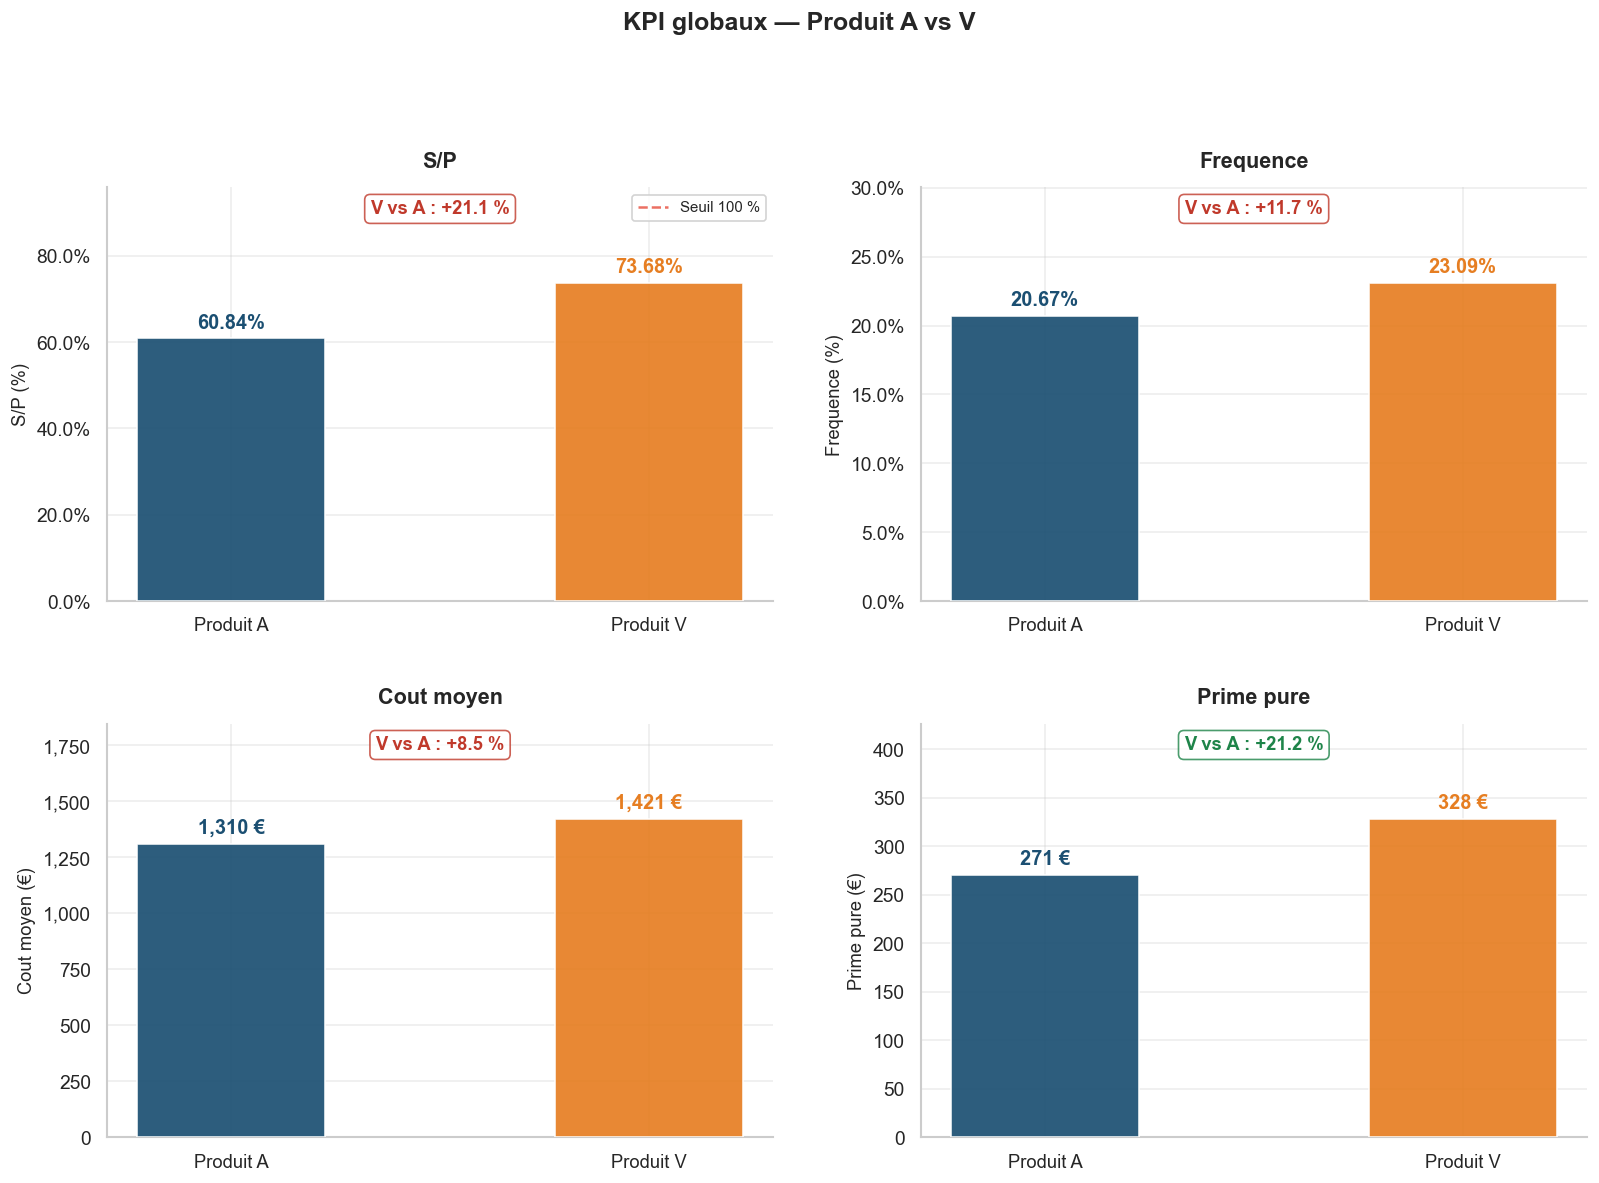

In [26]:
# ── Graphique KPI global : 4 métriques avec delta V/A ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

kpis_conf = [
    ('S/P',       'S/P (%)',       lambda v: v * 100,  True),
    ('Frequence', 'Frequence (%)', lambda v: v * 100,  False),   # % partout
    ('Cout moyen','Cout moyen (€)',lambda v: v,        False),
    ('Prime pure','Prime pure (€)',lambda v: v,        False),
]

for ax, (col, ylabel, transf, show100) in zip(axes, kpis_conf):
    vals = [transf(kpi_global.loc[p, col]) for p in ['A', 'V']]

    bars = ax.bar(['Produit A', 'Produit V'], vals,
                  color=PAL_AV, width=0.45, edgecolor='white',
                  linewidth=1.0, alpha=0.92, zorder=3)

    for bar, v, c in zip(bars, vals, PAL_AV):
        if col in ('S/P', 'Frequence'):
            label = f'{v:.2f}%'
        else:
            label = f'{v:,.0f} €'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                label, ha='center', va='bottom',
                fontsize=12, fontweight='bold', color=c)

    d     = (vals[1] - vals[0]) / abs(vals[0]) * 100
    col_d = COLOR_BAD if (col in ('S/P', 'Cout moyen', 'Frequence') and d > 0) else COLOR_OK
    sign  = '+' if d > 0 else ''
    ax.text(0.5, 0.97, f'V vs A : {sign}{d:.1f} %',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=11, fontweight='bold', color=col_d,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=col_d, alpha=0.8))

    if show100:
        ax.axhline(100, color=COLOR_100, ls='--', lw=1.5, alpha=0.8, label='Seuil 100 %')
        ax.legend(fontsize=9)

    if col in ('S/P', 'Frequence'):
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

    ax.set_title(col, pad=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.30)
    ax.tick_params(axis='x', labelsize=11)

fig.suptitle('KPI globaux — Produit A vs V', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.5)
plt.savefig('kpi_global.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. KPI par Garantie

In [27]:

def plot_kpi_chart(x_labels, sp_a, sp_v, freq_a, freq_v,
                   cm_a, cm_v, titre, filename):
    """
    Graphique 3 panneaux empiles (design lisible et professionnel) :
      Panneau 1 : S/P A vs V  — barres groupees + zones risque + annotations delta
      Panneau 2 : Frequence   — barres groupees en %
      Panneau 3 : Cout moyen  — barres groupees en euros
    """
    n = len(x_labels)
    x = np.arange(n)
    w = 0.35

    # ── Conversion des valeurs ────────────────────────────────────────────────
    sp_a_   = np.nan_to_num(np.array(sp_a,   dtype=float)) * 100
    sp_v_   = np.nan_to_num(np.array(sp_v,   dtype=float)) * 100
    freq_a_ = np.nan_to_num(np.array(freq_a, dtype=float)) * 100
    freq_v_ = np.nan_to_num(np.array(freq_v, dtype=float)) * 100
    cm_a_   = np.nan_to_num(np.array(cm_a,   dtype=float))
    cm_v_   = np.nan_to_num(np.array(cm_v,   dtype=float))

    top_sp   = max(float(np.nanmax(sp_a_)),   float(np.nanmax(sp_v_)),   115) * 1.32
    top_freq = max(float(np.nanmax(freq_a_)), float(np.nanmax(freq_v_)), 1.0) * 1.38
    top_cm   = max(float(np.nanmax(cm_a_)),   float(np.nanmax(cm_v_)),   100) * 1.32

    # ── Mise en page : 3 panneaux empiles, axe X partage ─────────────────────
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(max(13, n * 1.6), 16),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 2, 2], 'hspace': 0.28},
    )
    fig.suptitle(titre, fontsize=14, fontweight='bold', y=1.01)

    # ══════════════════════════════════════════════════════════════════════════
    # PANNEAU 1 — S/P
    # ══════════════════════════════════════════════════════════════════════════
    # Zones de risque en fond
    ax1.axhspan(  0,   70,    alpha=0.08, color='#27AE60', zorder=0)
    ax1.axhspan( 70,  100,    alpha=0.08, color='#F39C12', zorder=0)
    ax1.axhspan(100,  top_sp, alpha=0.08, color='#E74C3C', zorder=0)

    ba1 = ax1.bar(x - w/2, sp_a_, w, color=COLOR_A, alpha=0.90,
                  edgecolor='white', linewidth=0.8, zorder=3, label='Produit A')
    bv1 = ax1.bar(x + w/2, sp_v_, w, color=COLOR_V, alpha=0.90,
                  edgecolor='white', linewidth=0.8, zorder=3, label='Produit V')
    ax1.axhline(100, color=COLOR_100, ls='--', lw=1.8, alpha=0.85,
                zorder=4, label='Seuil 100 %')

    # Couleur des labels selon niveau de S/P
    def _lbl_sp(v):
        return COLOR_OK if v < 70 else (COLOR_WARN if v < 100 else COLOR_BAD)

    for bar, v in zip(ba1, sp_a_):
        if v > 0:
            ax1.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + top_sp * 0.012,
                     f'{v:.0f}%', ha='center', va='bottom',
                     fontsize=8.5, fontweight='bold', color=_lbl_sp(v))
    for bar, v in zip(bv1, sp_v_):
        if v > 0:
            ax1.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + top_sp * 0.012,
                     f'{v:.0f}%', ha='center', va='bottom',
                     fontsize=8.5, fontweight='bold', color=_lbl_sp(v))

    # Annotations delta V−A au-dessus de chaque paire
    for i, (va, vv) in enumerate(zip(sp_a_, sp_v_)):
        if va > 0 or vv > 0:
            delta = vv - va
            sign  = '+' if delta >= 0 else ''
            col_d = COLOR_BAD if delta > 3 else (COLOR_OK if delta < -3 else COLOR_WARN)
            ypos  = max(va, vv) + top_sp * 0.055
            ax1.annotate(f'{sign}{delta:.0f}pp',
                         xy=(i, ypos), ha='center', va='bottom',
                         fontsize=7.5, color=col_d, fontweight='bold',
                         bbox=dict(boxstyle='round,pad=0.18', fc='white',
                                   ec=col_d, alpha=0.82, lw=0.8))

    # Legende : produits + zones de risque
    p_ok   = mpatches.Patch(color='#27AE60', alpha=0.40, label='< 70 %  favorable')
    p_warn = mpatches.Patch(color='#F39C12', alpha=0.40, label='70–100 %  attention')
    p_bad  = mpatches.Patch(color='#E74C3C', alpha=0.40, label='> 100 %  critique')
    h, l = ax1.get_legend_handles_labels()
    ax1.legend(h + [p_ok, p_warn, p_bad],
               l + ['< 70 %  favorable', '70–100 %  attention', '> 100 %  critique'],
               loc='upper right', fontsize=8.5, ncol=3, framealpha=0.93,
               edgecolor='#BDC3C7')

    ax1.set_ylabel('S/P (%)', fontsize=11, fontweight='bold')
    ax1.set_ylim(0, top_sp)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax1.set_title('S/P  (Sinistres / Primes)', fontsize=11, pad=8, loc='left',
                  color='#2C3E50')

    # ══════════════════════════════════════════════════════════════════════════
    # PANNEAU 2 — Frequence (%)
    # ══════════════════════════════════════════════════════════════════════════
    ba2 = ax2.bar(x - w/2, freq_a_, w, color=COLOR_A, alpha=0.90,
                  edgecolor='white', linewidth=0.8, label='Produit A')
    bv2 = ax2.bar(x + w/2, freq_v_, w, color=COLOR_V, alpha=0.90,
                  edgecolor='white', linewidth=0.8, label='Produit V')

    for bar, v in zip(ba2, freq_a_):
        if v > 0:
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + top_freq * 0.02,
                     f'{v:.2f}%', ha='center', va='bottom',
                     fontsize=8, fontweight='bold', color=COLOR_A)
    for bar, v in zip(bv2, freq_v_):
        if v > 0:
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + top_freq * 0.02,
                     f'{v:.2f}%', ha='center', va='bottom',
                     fontsize=8, fontweight='bold', color=COLOR_V)

    ax2.set_ylabel('Frequence (%)', fontsize=11, fontweight='bold')
    ax2.set_ylim(0, top_freq)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
    ax2.legend(loc='upper right', fontsize=8.5, framealpha=0.93, edgecolor='#BDC3C7')
    ax2.set_title('Frequence  (Nb sinistres / Exposition)', fontsize=11, pad=8,
                  loc='left', color='#2C3E50')

    # ══════════════════════════════════════════════════════════════════════════
    # PANNEAU 3 — Cout moyen
    # ══════════════════════════════════════════════════════════════════════════
    ba3 = ax3.bar(x - w/2, cm_a_, w, color=COLOR_A, alpha=0.90,
                  edgecolor='white', linewidth=0.8, label='Produit A')
    bv3 = ax3.bar(x + w/2, cm_v_, w, color=COLOR_V, alpha=0.90,
                  edgecolor='white', linewidth=0.8, label='Produit V')

    for bar, v in zip(ba3, cm_a_):
        if v > 0:
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + top_cm * 0.02,
                     f'{v:,.0f}', ha='center', va='bottom',
                     fontsize=8, fontweight='bold', color=COLOR_A)
    for bar, v in zip(bv3, cm_v_):
        if v > 0:
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + top_cm * 0.02,
                     f'{v:,.0f}', ha='center', va='bottom',
                     fontsize=8, fontweight='bold', color=COLOR_V)

    ax3.set_ylabel('Cout moyen (€)', fontsize=11, fontweight='bold')
    ax3.set_ylim(0, top_cm)
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax3.legend(loc='upper right', fontsize=8.5, framealpha=0.93, edgecolor='#BDC3C7')
    ax3.set_title('Cout moyen  (Charge / Nb sinistres)', fontsize=11, pad=8,
                  loc='left', color='#2C3E50')

    # ── Axe X commun (affiche uniquement sur le panneau bas) ─────────────────
    ax3.set_xticks(x)
    ax3.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=11)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

print('Helper plot_kpi_chart OK  (3 panneaux empiles)')


Helper plot_kpi_chart OK  (3 panneaux empiles)


In [28]:
# ── Calcul KPI par garantie ───────────────────────────────────────────────────
rows = []
for prod in ['A', 'V']:
    sub = df_av[df_av['produit'] == prod]
    for gar in GARANTIES:
        r = calc_kpi(sub, gar=gar)
        r['Produit']  = prod
        r['Garantie'] = GAR_LABEL[gar]
        rows.append(r)
kpi_gar = pd.DataFrame(rows)

# ── Tableaux stylisés ─────────────────────────────────────────────────────────
def tableau_kpi(df_gar, col, fmt_fn, label):
    piv = (df_gar
           .pivot_table(index='Garantie', columns='Produit', values=col, aggfunc='first')
           .reindex(GAR_ORDER))
    piv['Ecart V/A'] = (piv['V'] - piv['A']) / piv['A'].abs() * 100
    piv_fmt = piv[['A', 'V']].applymap(fmt_fn)
    piv_fmt['Ecart V/A'] = piv['Ecart V/A'].apply(lambda x: f'{x:+.1f} %')
    st = (piv_fmt.style
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-weight','bold'),('font-size','13px'),('color','#1B4F72')]},
              {'selector': 'thead th',
               'props': [('background-color','#1B4F72'),('color','white'),
                         ('font-weight','bold'),('text-align','center')]},
              {'selector': 'td',
               'props': [('text-align','right'),('padding','6px 16px')]},
          ])
          .set_caption(label)
          .map(_ecart_color, subset=['Ecart V/A']))
    if col == 'S/P':
        st = st.map(_sp_color, subset=['A', 'V'])
    return st

display(tableau_kpi(kpi_gar, 'S/P',       lambda v: f'{v:.1%}',     'S/P'))
display(tableau_kpi(kpi_gar, 'Frequence', lambda v: f'{v:.4f}',     'Frequence'))
display(tableau_kpi(kpi_gar, 'Cout moyen',lambda v: f'{v:,.0f}',    'Cout moyen'))
display(tableau_kpi(kpi_gar, 'Prime pure',lambda v: f'{v:,.1f}',    'Prime pure'))

Produit,A,V,Ecart V/A
Garantie,,,
RC,66.5%,84.7%,+27.3 %
BDG,73.7%,72.8%,-1.1 %
INC_VOL,45.0%,44.5%,-1.1 %
DOM,53.5%,68.4%,+27.8 %


Produit,A,V,Ecart V/A
Garantie,,,
RC,0.0579,0.0696,+20.2 %
BDG,0.0779,0.0829,+6.4 %
INC_VOL,0.0259,0.0266,+2.9 %
DOM,0.0450,0.0517,+15.0 %


Produit,A,V,Ecart V/A
Garantie,,,
RC,"2,531","2,680",+5.9 %
BDG,426,394,-7.5 %
INC_VOL,"1,042","1,000",-4.0 %
DOM,"1,426","1,591",+11.5 %


Produit,A,V,Ecart V/A
Garantie,,,
RC,146.6,186.6,+27.3 %
BDG,33.2,32.7,-1.5 %
INC_VOL,27.0,26.6,-1.2 %
DOM,64.2,82.3,+28.2 %


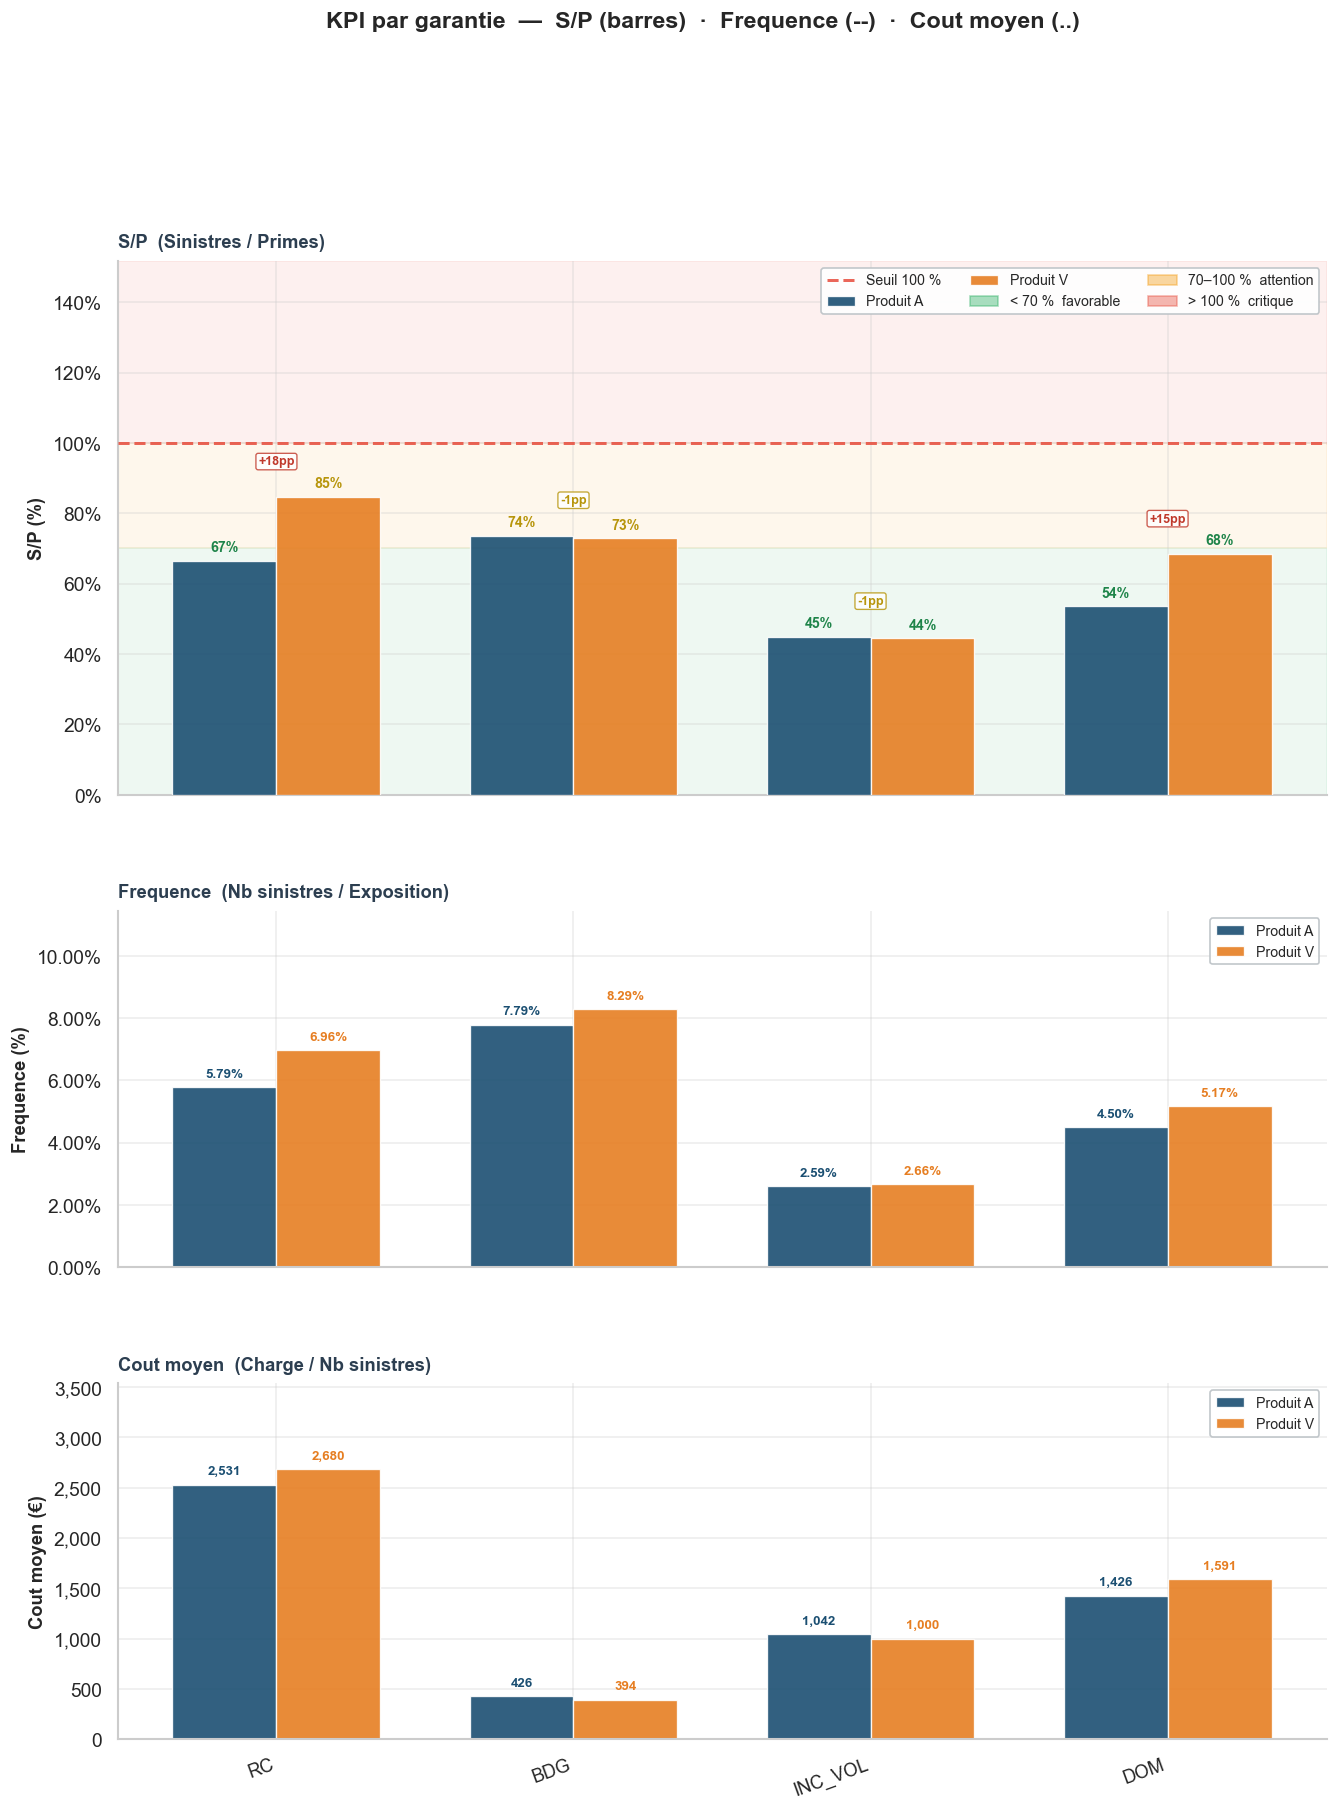

In [105]:

# ── Graphique KPI par garantie — 3 axes (barres S/P + courbes Freq + CM) ──────
def get_gar(prod, col):
    sub = kpi_gar[kpi_gar['Produit'] == prod].set_index('Garantie').reindex(GAR_ORDER)
    return sub[col].fillna(0).tolist()

plot_kpi_chart(
    x_labels = GAR_ORDER,
    sp_a     = get_gar('A', 'S/P'),       sp_v   = get_gar('V', 'S/P'),
    freq_a   = get_gar('A', 'Frequence'), freq_v = get_gar('V', 'Frequence'),
    cm_a     = get_gar('A', 'Cout moyen'),cm_v   = get_gar('V', 'Cout moyen'),
    titre    = 'KPI par garantie  —  S/P (barres)  ·  Frequence (--)  ·  Cout moyen (..)',
    filename = 'kpi_garanties.png',
)


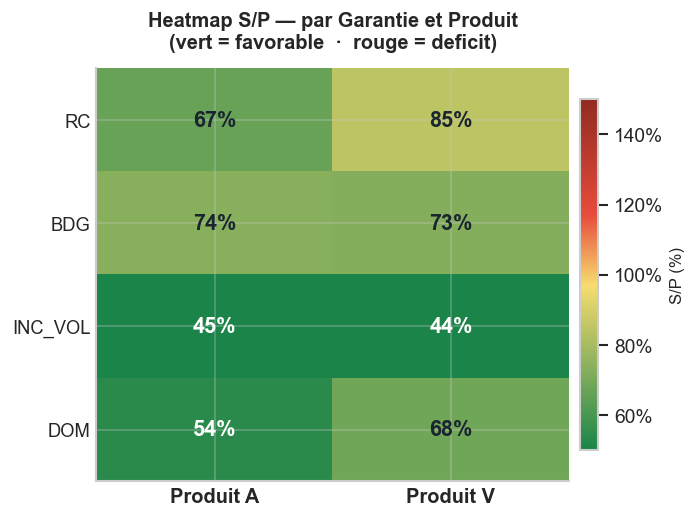

Heatmap enregistree : heatmap_sp_garantie.png


In [29]:

# ── Heatmap S/P par garantie × produit ───────────────────────────────────────
# Lecture : couleur verte = S/P faible (favorable)
#            couleur rouge = S/P elevee (defavorable)
from matplotlib.colors import LinearSegmentedColormap

sp_piv = (
    kpi_gar.pivot_table(index='Garantie', columns='Produit', values='S/P', aggfunc='first')
    .reindex(GAR_ORDER) * 100
)

# Palette verte → jaune → rouge centree sur 100 %
nodes    = [0.0, 0.47, 0.67, 1.0]          # 50 % / 70 % / 100 % / 150 %
couleurs = ['#1A8449', '#F7DC6F', '#E74C3C', '#922B21']
cmap_sp  = LinearSegmentedColormap.from_list('sp', list(zip(nodes, couleurs)))

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(sp_piv.values, cmap=cmap_sp, vmin=50, vmax=150, aspect='auto')

# Annotations valeurs
for i in range(len(GAR_ORDER)):
    for j, prod in enumerate(['A', 'V']):
        v = sp_piv.loc[GAR_ORDER[i], prod]
        text_col = 'white' if v > 110 or v < 65 else '#1A252F'
        ax.text(j, i, f'{v:.0f}%',
                ha='center', va='center',
                fontsize=13, fontweight='bold', color=text_col)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Produit A', 'Produit V'], fontsize=12, fontweight='bold')
ax.set_yticks(range(len(GAR_ORDER)))
ax.set_yticklabels(GAR_ORDER, fontsize=11)
ax.tick_params(length=0)

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('S/P (%)', fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

ax.set_title('Heatmap S/P — par Garantie et Produit\n'
             '(vert = favorable  ·  rouge = deficit)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('heatmap_sp_garantie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap enregistree : heatmap_sp_garantie.png')


---
## 5. Analyse Univariée

Pour chaque variable (**Carburant**, **Âge conducteur**, **Marque**), trois graphiques sont générés :

| Graphique | Ce qu'il montre | Comment le lire |
|---|---|---|
| **Distribution** | Part du portefeuille par modalité (A vs V) | Comparer les structures — un S/P différent peut s'expliquer par une composition différente |
| **KPI par modalité** | S/P · Fréquence · Coût moyen (3 panneaux) | La **zone colorée** du S/P indique le niveau de risque ; les **annotations** Δpp montrent l'écart V−A |
| **Profil de risque** | Fréquence (%) × Coût moyen (scatter) | Chaque point = une modalité ; la **position horizontale** = fréquence, la **verticale** = coût moyen. Taille ∝ nb contrats. Permet de savoir si l'écart de S/P vient de la **fréquence** (point décalé à droite) ou du **coût** (point décalé vers le haut) |

> **Astuce** : les **lignes pointillées grises** du scatter représentent la moyenne de l'ensemble — les points en haut à droite sont les modalités les plus risquées.

In [30]:

def analyse_univarie(variable, ordre, titre, filename_prefix):
    """
    Pour une variable donnee, genere 3 graphiques :
      1. Distribution  : part du portefeuille par modalite (A vs V)
      2. KPI 3 panneaux: S/P + Frequence + Cout moyen (barres groupees)
      3. Profil risque : scatter Frequence x Cout moyen (taille = nb contrats)
         → montre si l'ecart S/P vient de la frequence ou du cout
    """
    ordre_present = [m for m in ordre if m in df_av[variable].values]
    rows = []
    for prod in ['A', 'V']:
        sub    = df_av[df_av['produit'] == prod]
        n_prod = len(sub)
        for modal in ordre_present:
            grp = sub[sub[variable] == modal]
            if len(grp) == 0:
                continue
            r = calc_kpi(grp)
            r.update({'Produit': prod, 'Modalite': modal,
                      'N': len(grp), 'Poids_%': len(grp) / n_prod * 100})
            rows.append(r)
    df_var = pd.DataFrame(rows)

    x = np.arange(len(ordre_present))
    w = 0.35

    # ── Figure 1 : Distribution ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (prod, color) in enumerate([('A', COLOR_A), ('V', COLOR_V)]):
        sv   = df_var[df_var['Produit'] == prod].set_index('Modalite')
        vals = [sv.loc[m, 'Poids_%'] if m in sv.index else 0 for m in ordre_present]
        bars = ax.bar(x + (i - 0.5) * w, vals, w,
                      label=f'Produit {prod}', color=color,
                      edgecolor='white', alpha=0.9)
        for bar, v in zip(bars, vals):
            if v > 0.5:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.3, f'{v:.0f}%',
                        ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(ordre_present, rotation=25, ha='right')
    ax.set_ylabel('Part du portefeuille (%)')
    ax.set_title(f'Distribution — {titre}', fontweight='bold')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{filename_prefix}_distrib.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 2 : KPI 3 panneaux (S/P + Freq + CM) ──────────────────────────
    def get(prod, col):
        sv = df_var[df_var['Produit'] == prod].set_index('Modalite')
        return [sv.loc[m, col] if m in sv.index and pd.notna(sv.loc[m, col]) else 0.0
                for m in ordre_present]

    plot_kpi_chart(
        x_labels = ordre_present,
        sp_a     = get('A', 'S/P'),        sp_v   = get('V', 'S/P'),
        freq_a   = get('A', 'Frequence'),  freq_v = get('V', 'Frequence'),
        cm_a     = get('A', 'Cout moyen'), cm_v   = get('V', 'Cout moyen'),
        titre    = f'{titre}  —  S/P · Frequence · Cout moyen',
        filename = f'{filename_prefix}_kpi.png',
    )

    # ── Figure 3 : Profil de risque (scatter Freq x Cout moyen) ──────────────
    # Chaque point = une modalite   taille = nb contrats   couleur = produit
    # Quadrants (lignes pointillees) = moyennes globales du dataset combine
    freq_moy_glob = df_var['Frequence'].mean() * 100
    cm_moy_glob   = df_var['Cout moyen'].dropna().mean()

    fig, ax = plt.subplots(figsize=(10, 6))

    for prod, color, marker, zord in [('A', COLOR_A, 'o', 4), ('V', COLOR_V, 's', 3)]:
        sv = df_var[df_var['Produit'] == prod].set_index('Modalite')
        for modal in ordre_present:
            if modal not in sv.index:
                continue
            row   = sv.loc[modal]
            freq  = row['Frequence'] * 100
            cm    = row['Cout moyen'] if pd.notna(row['Cout moyen']) else 0
            taille = max(row['N'] / 7, 25)
            ax.scatter(freq, cm, s=taille, color=color, alpha=0.80, marker=marker,
                       edgecolor='white', linewidth=1.2, zorder=zord)
            ax.annotate(f' {modal}', (freq, cm),
                        fontsize=8.5, color=color, fontweight='bold',
                        xytext=(4, 3), textcoords='offset points')

    # Quadrants
    ax.axvline(freq_moy_glob, color='#95A5A6', ls='--', lw=1.1, alpha=0.7,
               label=f'Freq moy. ({freq_moy_glob:.2f}%)')
    ax.axhline(cm_moy_glob,   color='#7F8C8D', ls='--', lw=1.1, alpha=0.7,
               label=f'CM moy. ({cm_moy_glob:,.0f} €)')

    # Annotations quadrants (coins)
    xmin, xmax = ax.get_xlim(); ymin, ymax = ax.get_ylim()
    quad_style = dict(fontsize=7.5, alpha=0.55, style='italic', color='#7F8C8D')
    ax.text(xmin + (xmax-xmin)*0.01, ymax * 0.97, 'Freq. faible / CM eleve',  va='top',    **quad_style)
    ax.text(xmax * 0.99,             ymax * 0.97, 'Freq. elevee / CM eleve',  va='top',    ha='right', **quad_style)
    ax.text(xmin + (xmax-xmin)*0.01, ymin + (ymax-ymin)*0.02, 'Freq. faible / CM faible', **quad_style)
    ax.text(xmax * 0.99,             ymin + (ymax-ymin)*0.02, 'Freq. elevee / CM faible', ha='right', **quad_style)

    # Legende
    h = [mpatches.Patch(color=COLOR_A, label='Produit A'),
         mpatches.Patch(color=COLOR_V, label='Produit V')]
    handles2, labels2 = ax.get_legend_handles_labels()
    ax.legend(h + handles2, ['Produit A', 'Produit V'] + labels2,
              fontsize=9, loc='best', framealpha=0.92)

    ax.set_xlabel('Frequence (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cout moyen (€)', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_title(f'Profil de risque — {titre}\n'
                 '(taille proportionnelle au nb de contrats · '
                 'quadrants = moyennes combinées A+V)',
                 fontsize=11, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig(f'{filename_prefix}_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_var

print('Helper analyse_univarie OK  (3 figures : distribution + KPI + profil risque)')


Helper analyse_univarie OK  (3 figures : distribution + KPI + profil risque)


### 5.1 Carburant

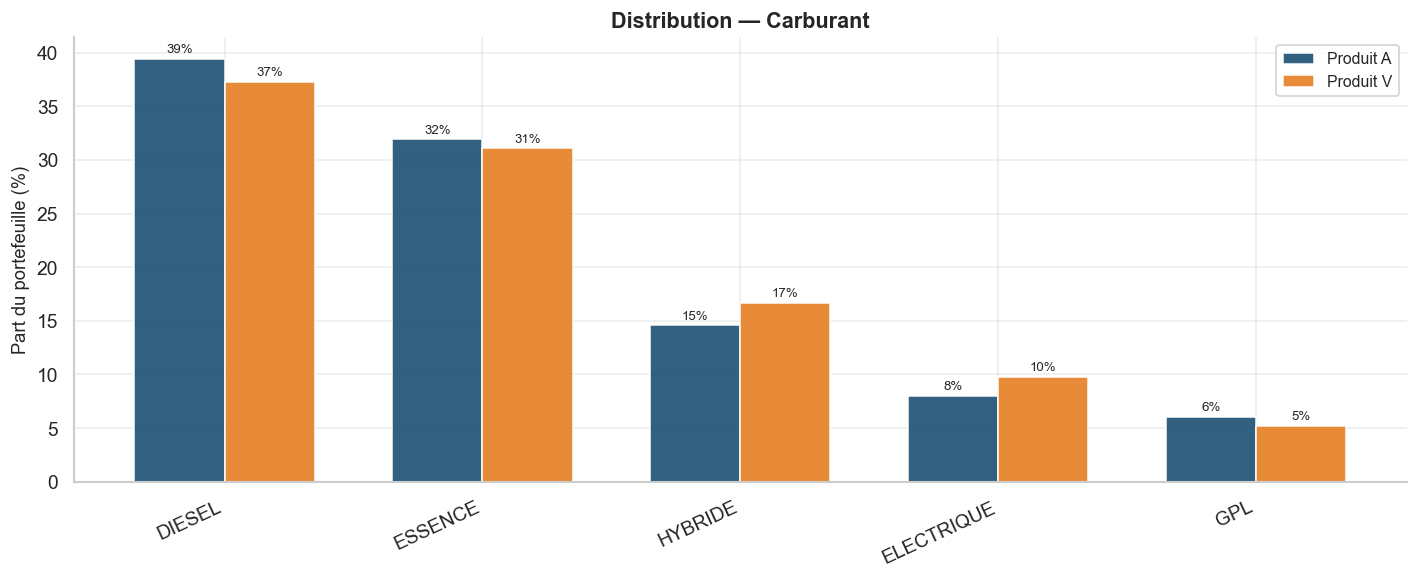

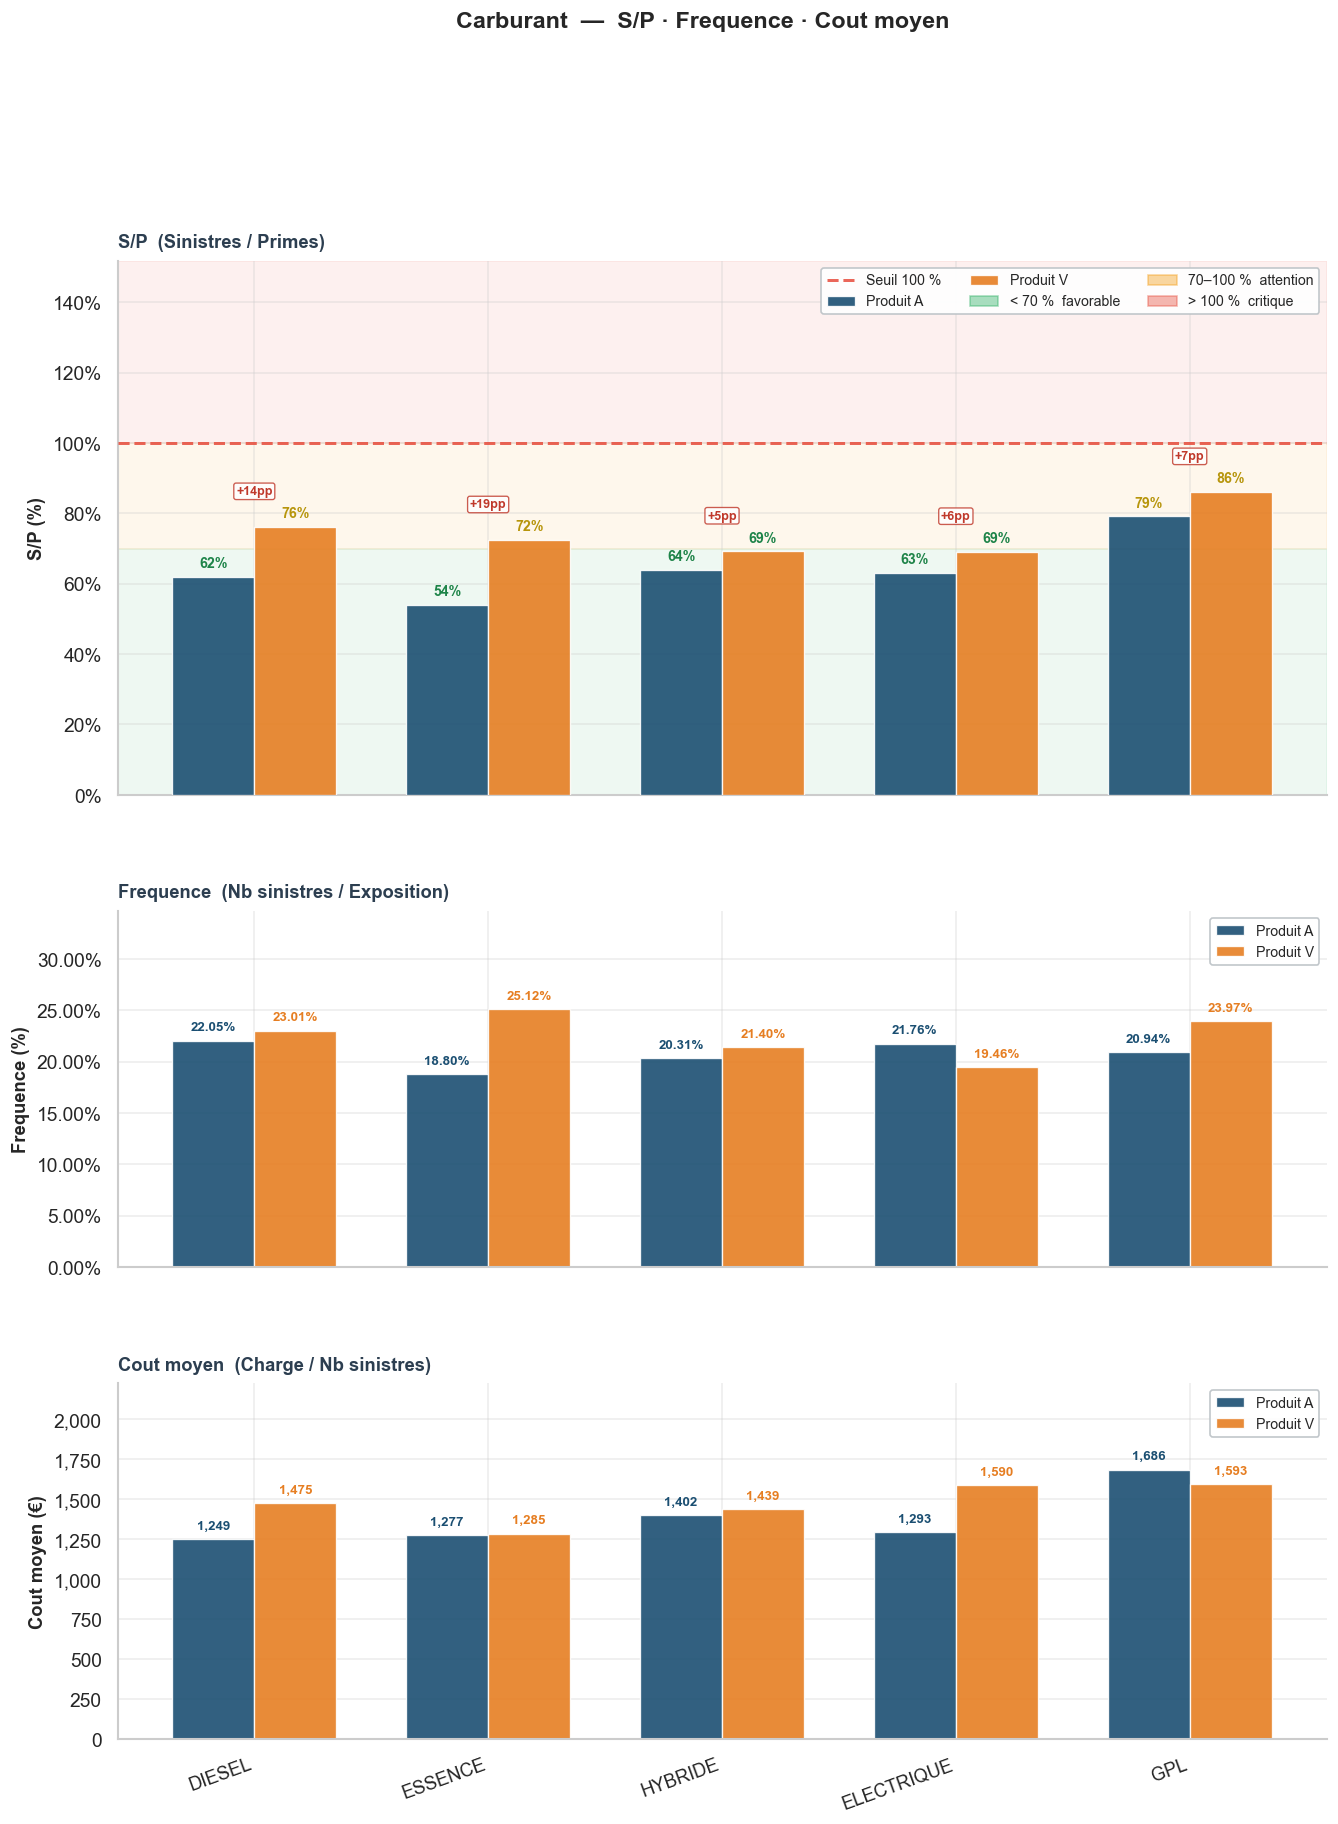

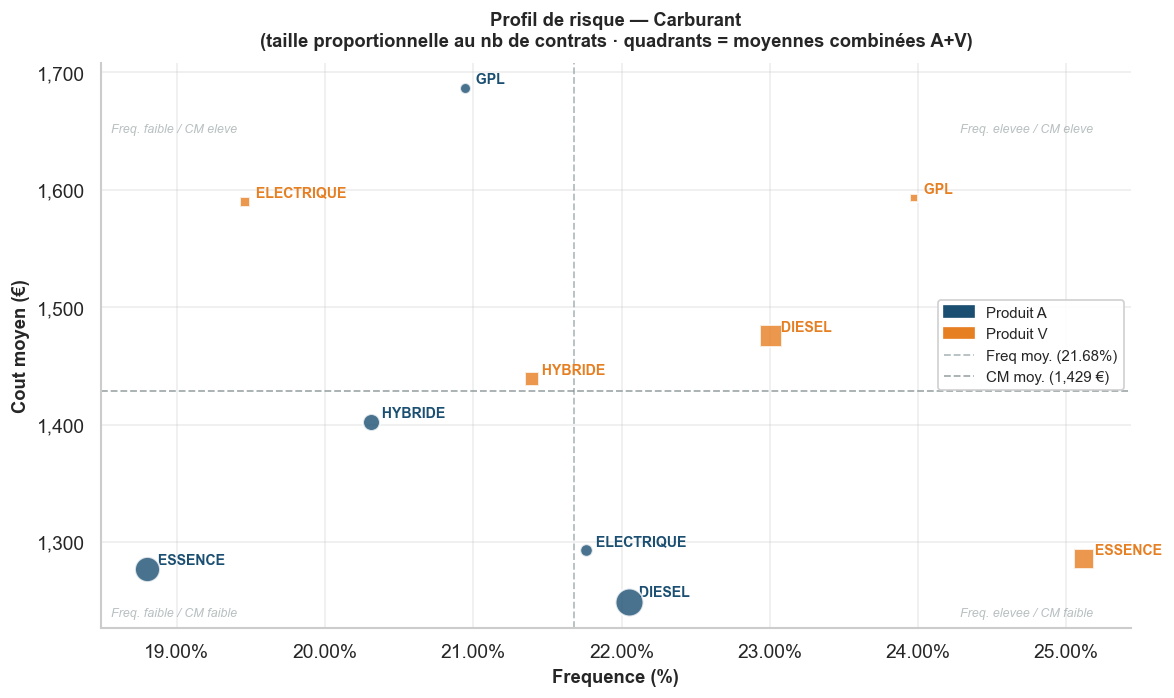

Cout moyen          Frequence             N          Poids_%        \
Produit             A        V         A    V        A        V       A     V   
Modalite                                                                        
DIESEL       1,249.20 1,475.35      0.22 0.23 1,972.00 1,118.00   39.44 37.27   
ELECTRIQUE   1,292.94 1,589.68      0.22 0.19   401.00   293.00    8.02  9.77   
ESSENCE      1,277.02 1,285.43      0.19 0.25 1,596.00   932.00   31.92 31.07   
GPL          1,686.24 1,592.83      0.21 0.24   302.00   156.00    6.04  5.20   
HYBRIDE      1,401.98 1,438.71      0.20 0.21   729.00   501.00   14.58 16.70   

            S/P       
Produit       A    V  
Modalite              
DIESEL     0.62 0.76  
ELECTRIQUE 0.63 0.69  
ESSENCE    0.54 0.72  
GPL        0.79 0.86  
HYBRIDE    0.64 0.69

In [31]:

df_carb = analyse_univarie('carburant', CARB_ORDER, 'Carburant', 'univarie_carburant')
display(df_carb.pivot_table(
    index='Modalite', columns='Produit',
    values=['N', 'Poids_%', 'S/P', 'Frequence', 'Cout moyen'],
).round(4))


### 5.2 Age conducteur

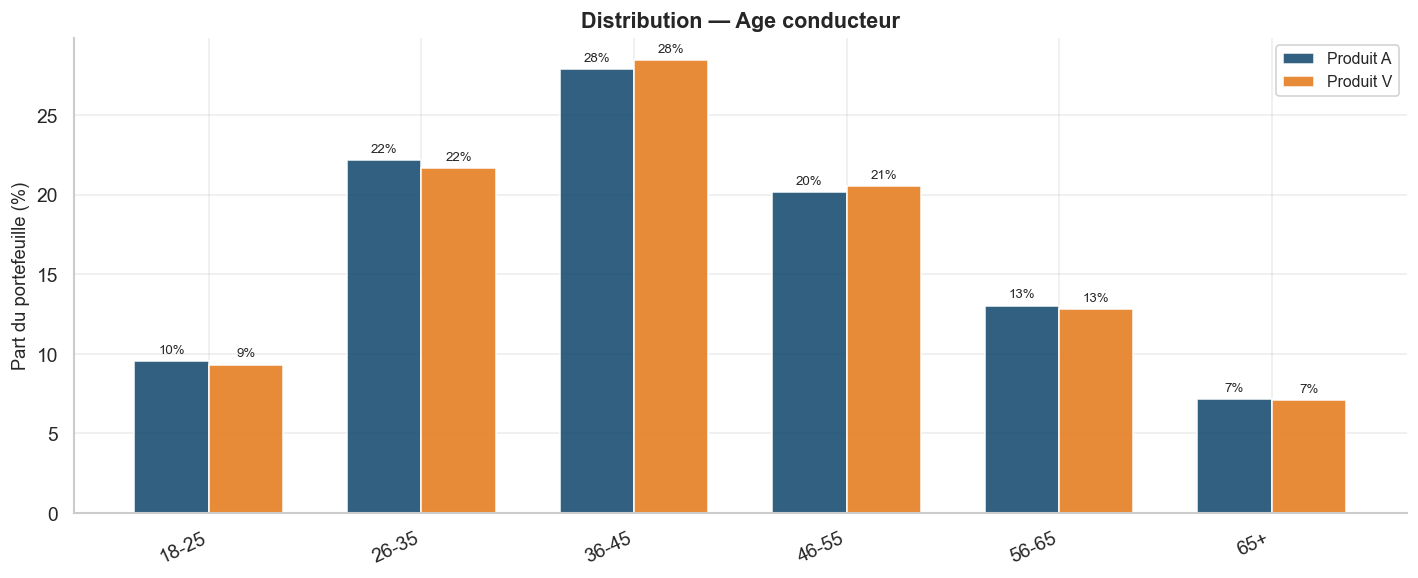

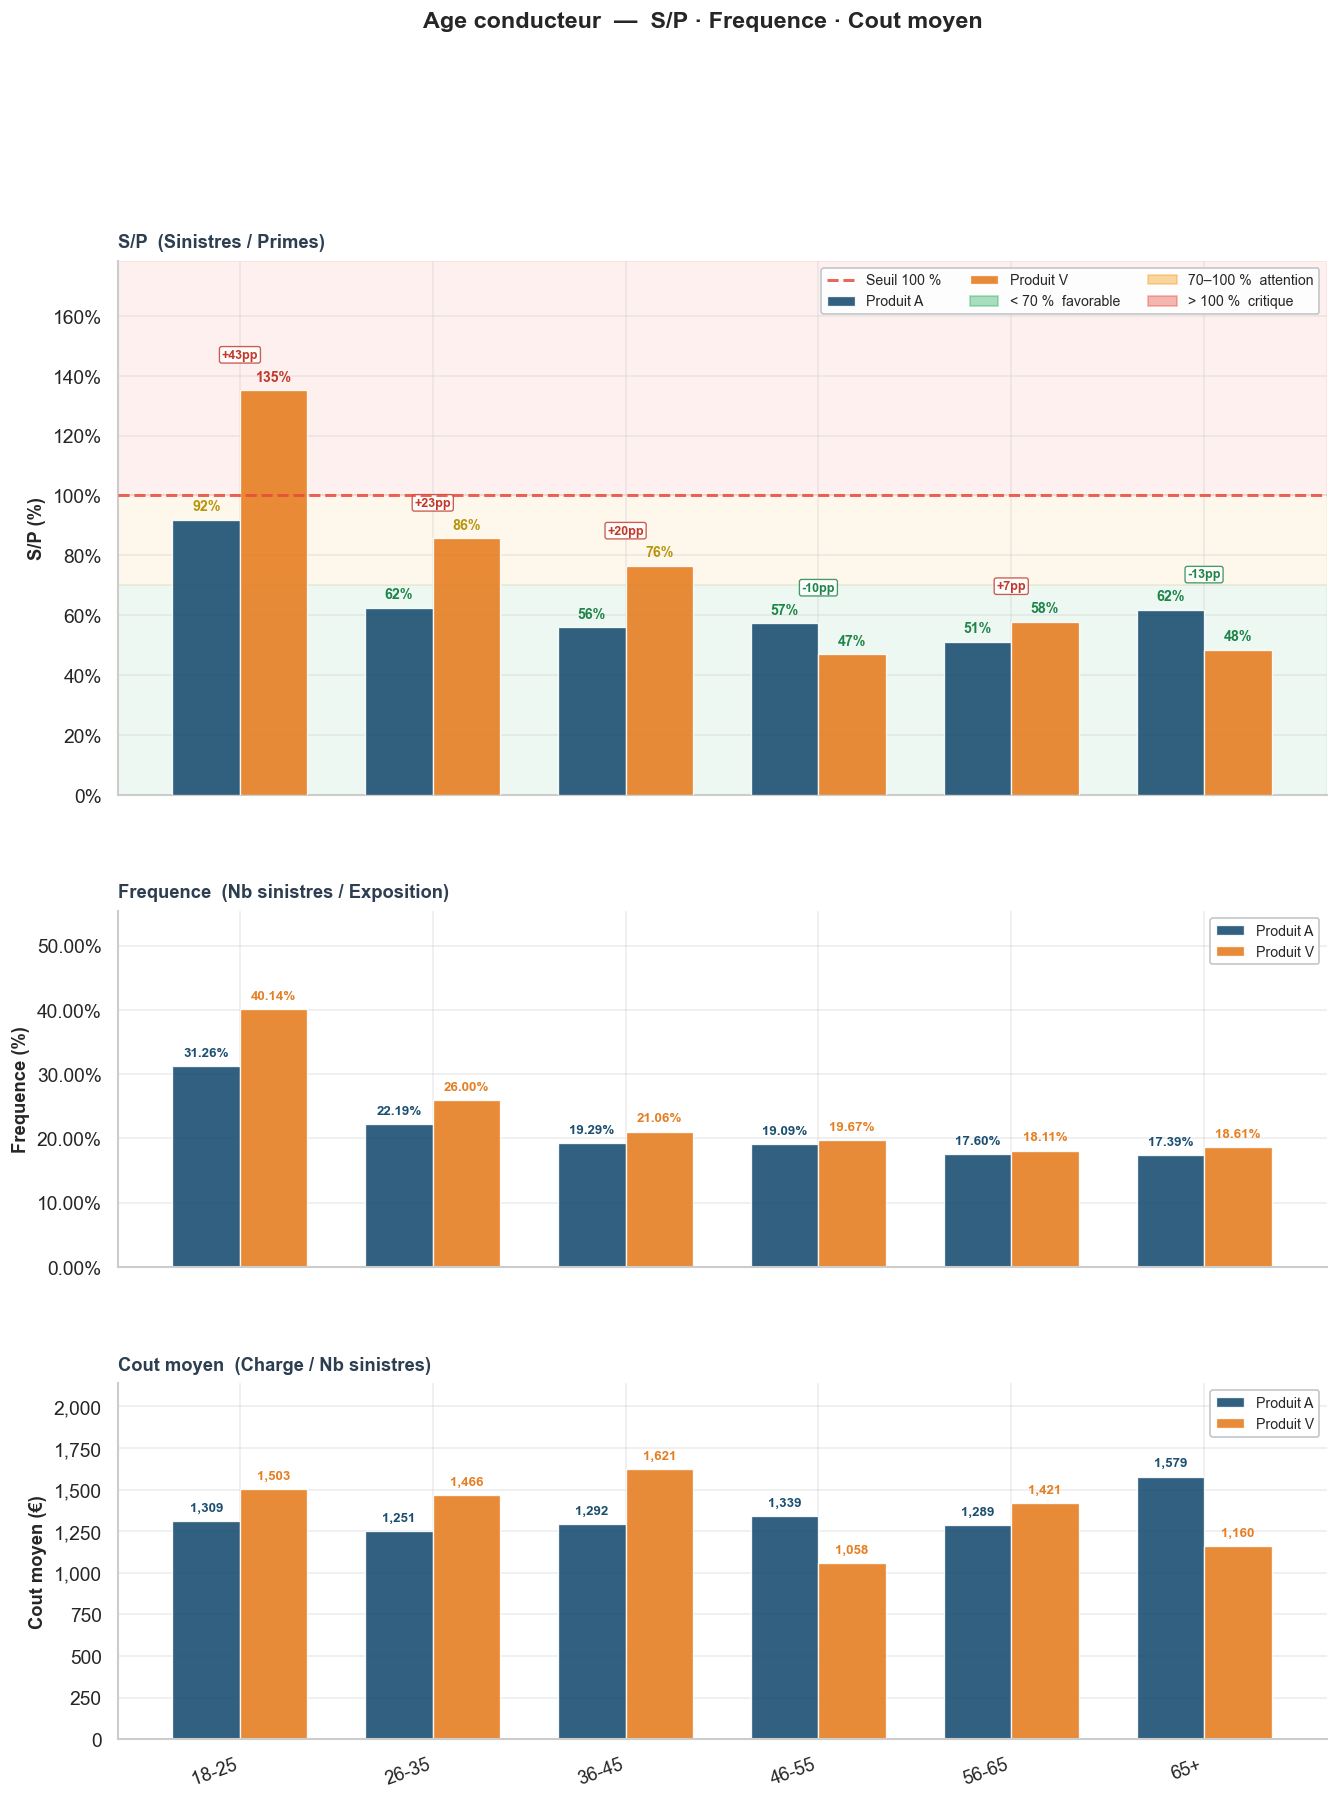

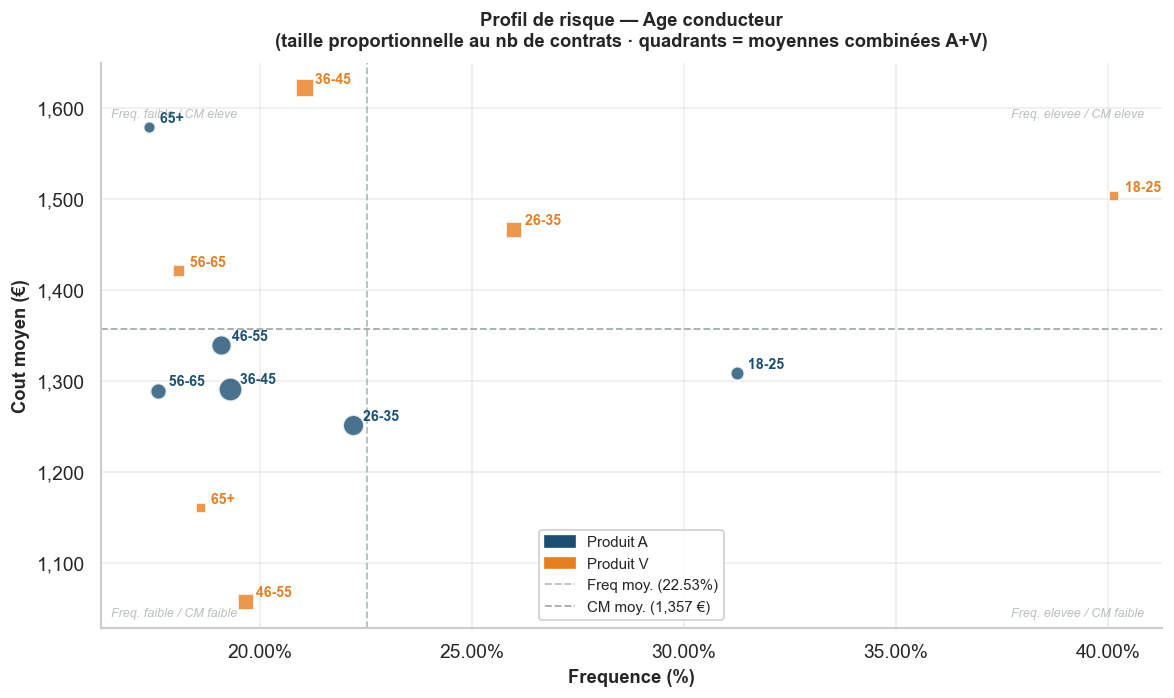

Cout moyen          Frequence             N        Poids_%        \
Produit           A        V         A    V        A      V       A     V   
Modalite                                                                    
18-25      1,308.53 1,502.80      0.31 0.40   478.00 280.00    9.56  9.33   
26-35      1,251.48 1,466.04      0.22 0.26 1,108.00 651.00   22.16 21.70   
36-45      1,291.61 1,621.04      0.19 0.21 1,395.00 854.00   27.90 28.47   
46-55      1,339.33 1,057.52      0.19 0.20 1,009.00 617.00   20.18 20.57   
56-65      1,289.29 1,420.55      0.18 0.18   652.00 385.00   13.04 12.83   
65+        1,578.54 1,160.47      0.17 0.19   358.00 213.00    7.16  7.10   

          S/P       
Produit     A    V  
Modalite            
18-25    0.92 1.35  
26-35    0.62 0.86  
36-45    0.56 0.76  
46-55    0.57 0.47  
56-65    0.51 0.58  
65+      0.62 0.48

In [32]:

df_age = analyse_univarie('age_bin', AGE_ORDER, 'Age conducteur', 'univarie_age')
display(df_age.pivot_table(
    index='Modalite', columns='Produit',
    values=['N', 'Poids_%', 'S/P', 'Frequence', 'Cout moyen'],
).round(4))


### 5.3 Marque

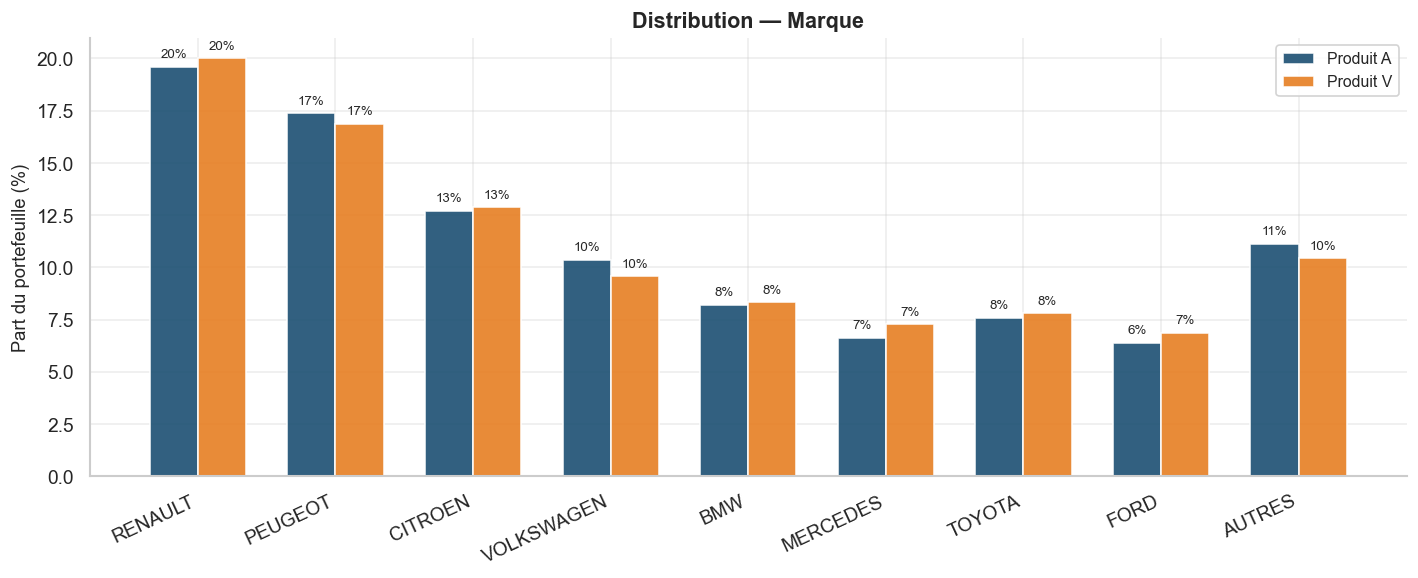

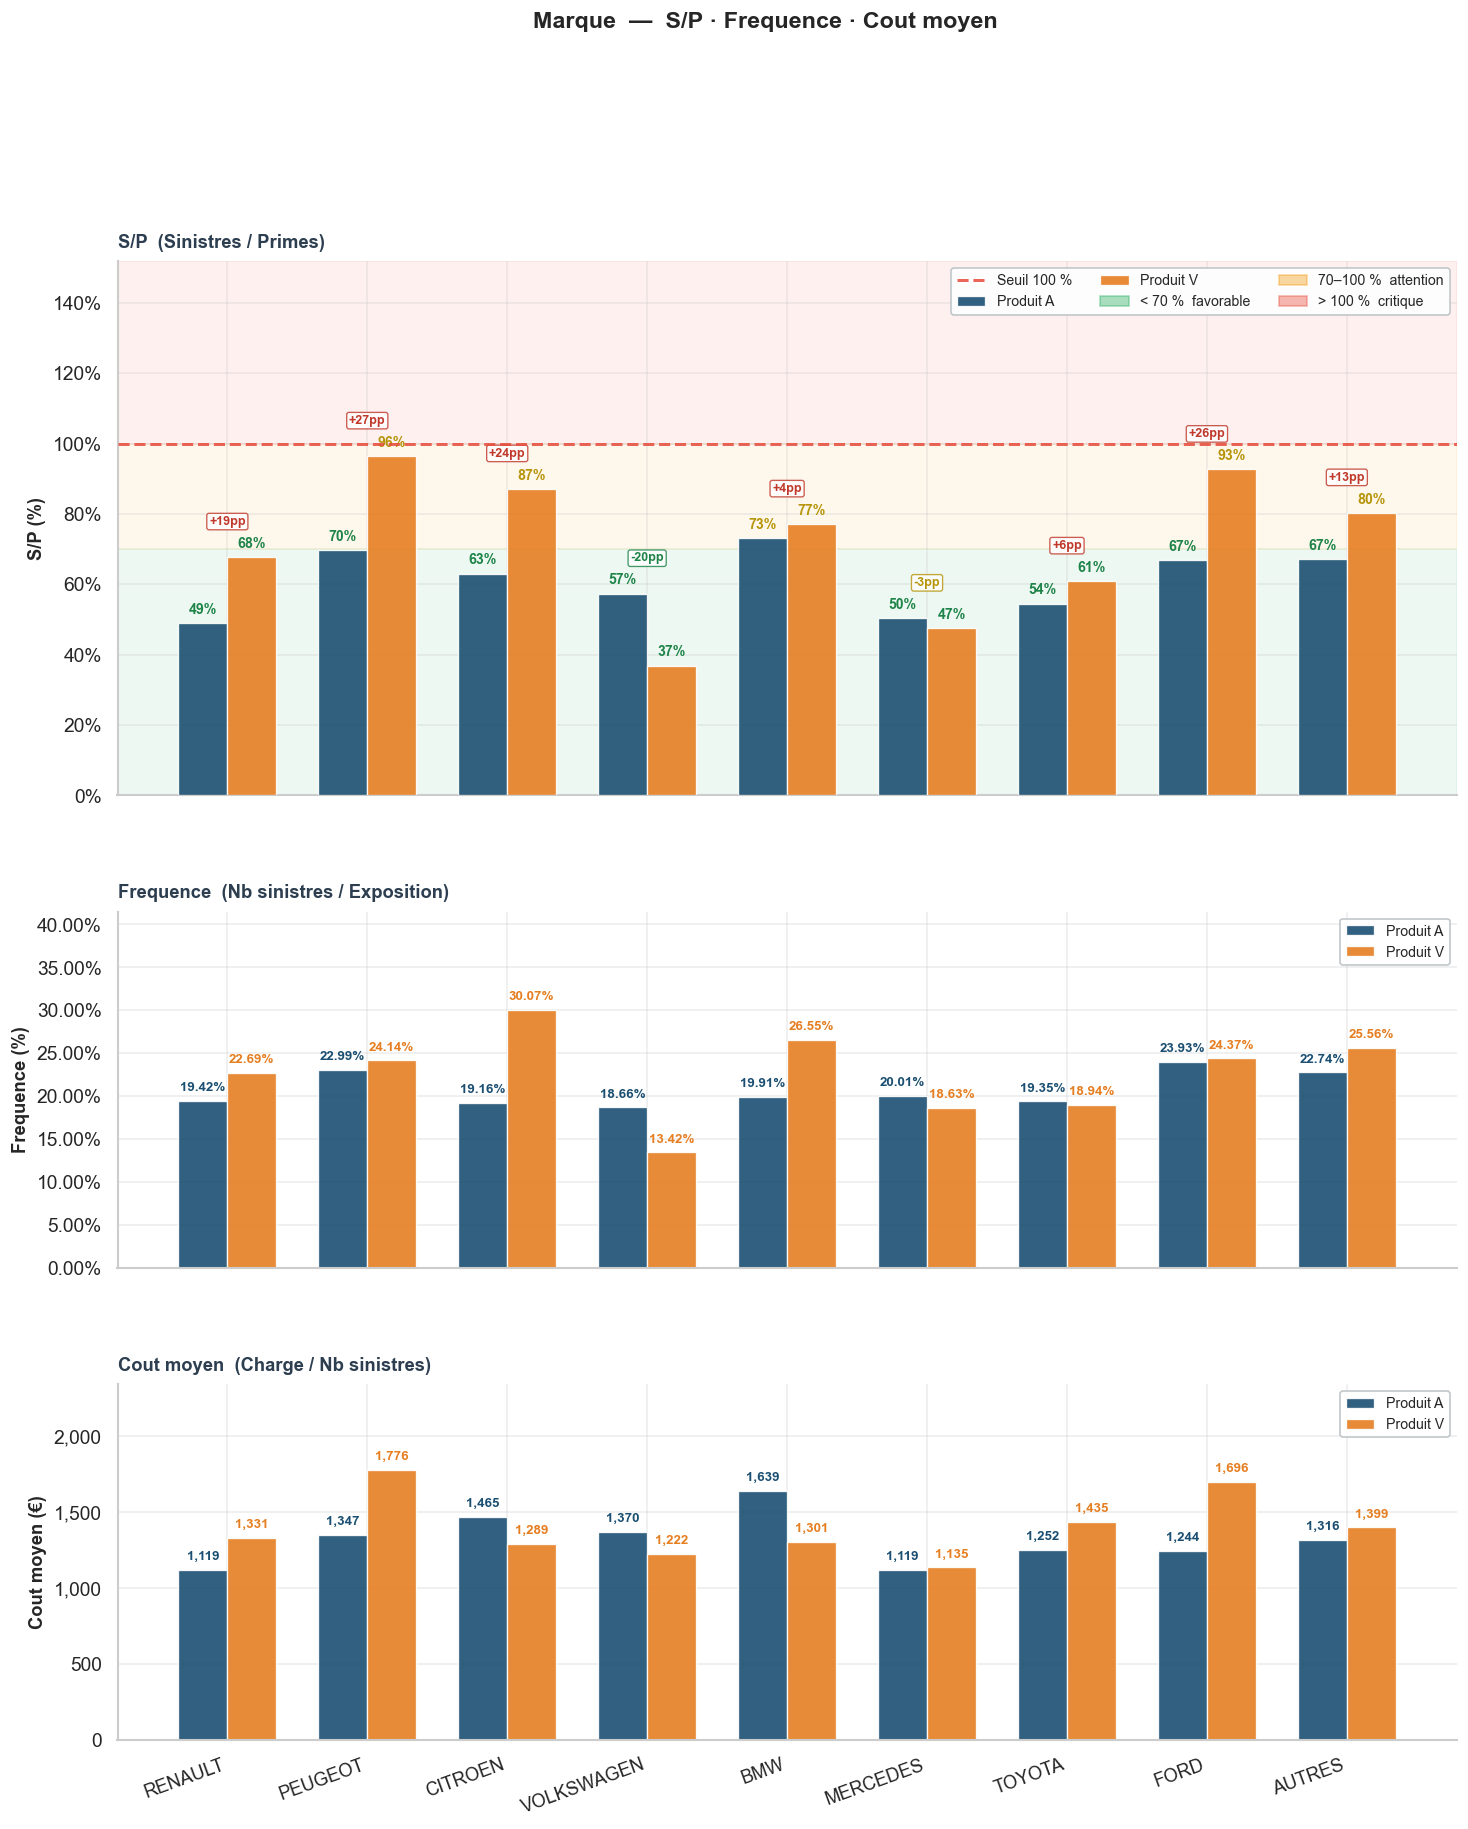

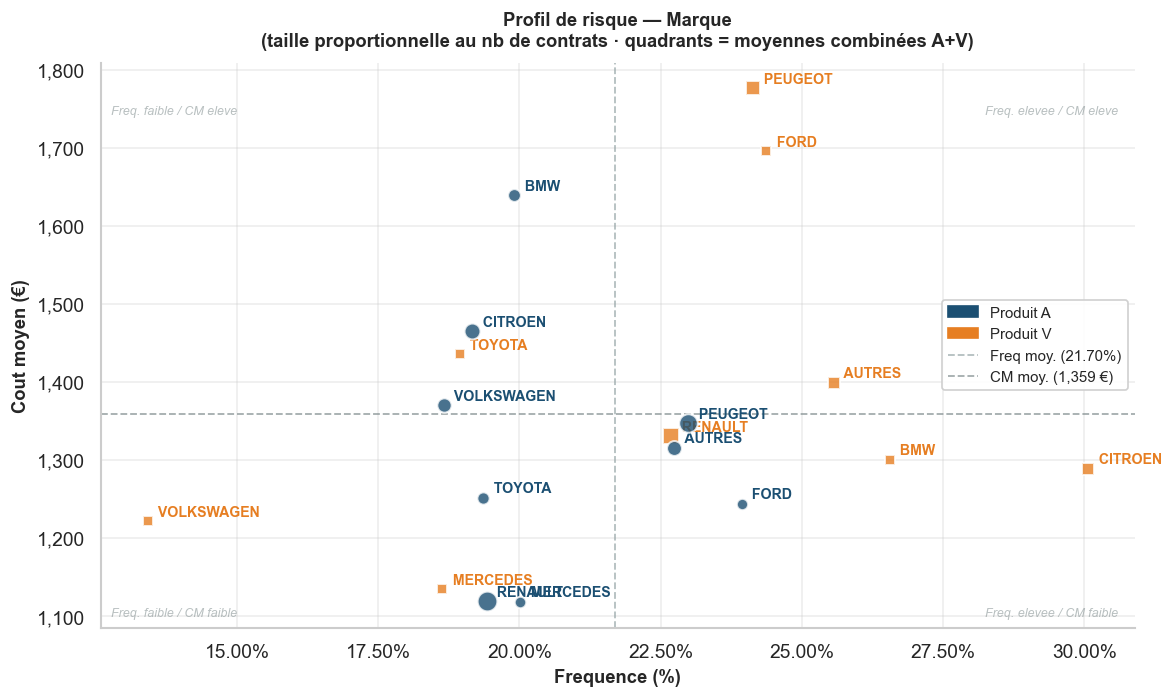

Cout moyen          Frequence           N        Poids_%        \
Produit             A        V         A    V      A      V       A     V   
Modalite                                                                    
AUTRES       1,316.02 1,399.17      0.23 0.26 556.00 313.00   11.12 10.43   
BMW          1,639.29 1,300.69      0.20 0.27 411.00 250.00    8.22  8.33   
CITROEN      1,465.40 1,289.10      0.19 0.30 636.00 386.00   12.72 12.87   
FORD         1,244.01 1,695.74      0.24 0.24 319.00 206.00    6.38  6.87   
MERCEDES     1,118.52 1,135.05      0.20 0.19 332.00 218.00    6.64  7.27   
PEUGEOT      1,347.06 1,775.69      0.23 0.24 869.00 506.00   17.38 16.87   
RENAULT      1,119.14 1,330.67      0.19 0.23 980.00 600.00   19.60 20.00   
TOYOTA       1,251.83 1,435.26      0.19 0.19 379.00 234.00    7.58  7.80   
VOLKSWAGEN   1,370.05 1,221.64      0.19 0.13 518.00 287.00   10.36  9.57   

            S/P       
Produit       A    V  
Modalite              
AUTRES     0.67 0.80  
BMW        0.73 0.77  
CITROEN    0.63 0.87  
FORD       0.67 0.93  
MERCEDES   0.50 0.47  
PEUGEOT    0.70 0.96  
RENAULT    0.49 0.68  
TOYOTA     0.55 0.61  
VOLKSWAGEN 0.57 0.37

In [33]:

df_marque = analyse_univarie('marque', MARQ_ORDER, 'Marque', 'univarie_marque')
display(df_marque.pivot_table(
    index='Modalite', columns='Produit',
    values=['N', 'Poids_%', 'S/P', 'Frequence', 'Cout moyen'],
).round(4))


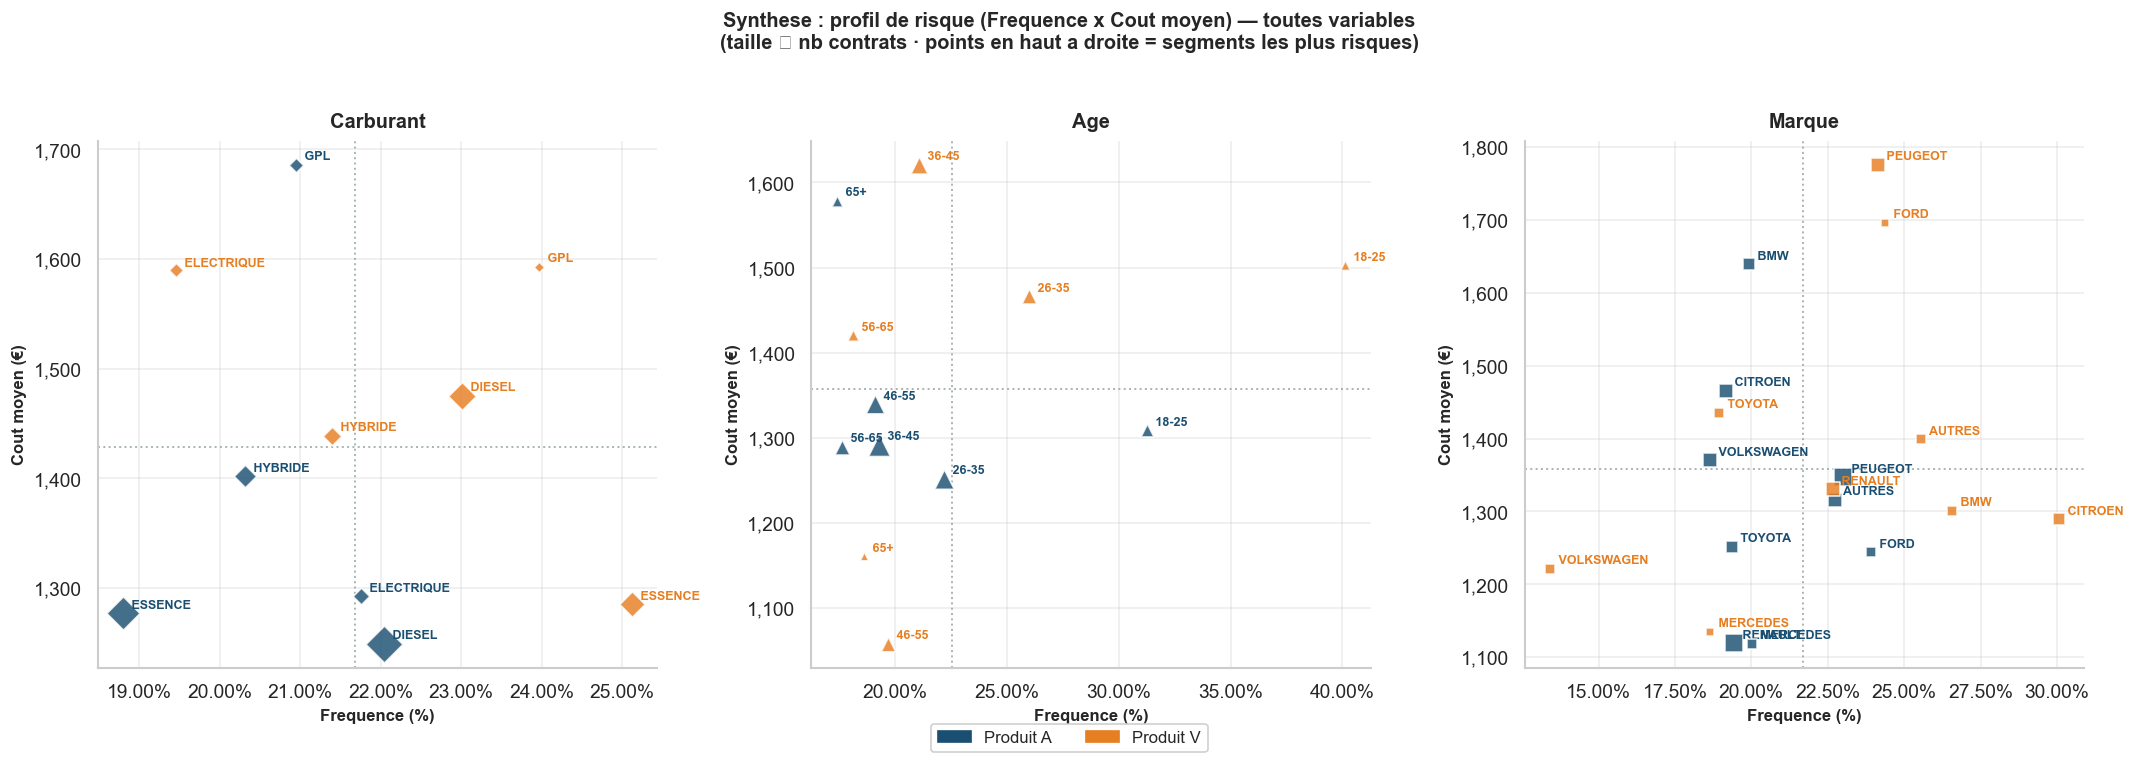

Synthese enregistree : synthese_bubble_univarie.png


In [34]:

# ── Synthese univariee : bubble chart toutes variables ────────────────────────
# Un point par (produit, modalite) pour les 3 variables
# X = Frequence (%)   Y = Cout moyen   Taille = nb contrats   Forme = variable
#
# Interpretation :
#   • Points en HAUT A DROITE  → frequence ET cout moyen eleves → risque maximum
#   • Ligne diagonale implicite → S/P proportionnel (Freq × CM ∝ Prime pure)
#   • Ecart A/V sur le meme modal → facteur de risque entre produits

VAR_CFG = [
    ('carburant', df_carb,   'D', CARB_ORDER),
    ('age_bin',   df_age,    '^', AGE_ORDER),
    ('marque',    df_marque, 's', MARQ_ORDER),
]
VAR_LABEL = {'carburant': 'Carburant', 'age_bin': 'Age', 'marque': 'Marque'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, (varname, df_v, mrkr, ordre) in zip(axes, VAR_CFG):
    ordre_p = [m for m in ordre if m in df_v['Modalite'].values]

    for prod, color in [('A', COLOR_A), ('V', COLOR_V)]:
        sv = df_v[df_v['Produit'] == prod].set_index('Modalite')
        for modal in ordre_p:
            if modal not in sv.index:
                continue
            row    = sv.loc[modal]
            freq   = row['Frequence'] * 100
            cm     = row['Cout moyen'] if pd.notna(row['Cout moyen']) else 0
            taille = max(row['N'] / 8, 20)
            ax.scatter(freq, cm, s=taille, color=color, alpha=0.82, marker=mrkr,
                       edgecolor='white', linewidth=1.0, zorder=3)
            ax.annotate(f' {modal}', (freq, cm),
                        fontsize=7.5, color=color, fontweight='bold',
                        xytext=(3, 3), textcoords='offset points')

    # Lignes moyennes
    fmoy = df_v['Frequence'].mean() * 100
    cmoy = df_v['Cout moyen'].dropna().mean()
    ax.axvline(fmoy, color='#95A5A6', ls=':', lw=1.2, alpha=0.8)
    ax.axhline(cmoy, color='#95A5A6', ls=':', lw=1.2, alpha=0.8)

    ax.set_xlabel('Frequence (%)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Cout moyen (€)', fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_title(VAR_LABEL[varname], fontsize=12, fontweight='bold', pad=8)

# Legende commune
h = [mpatches.Patch(color=COLOR_A, label='Produit A'),
     mpatches.Patch(color=COLOR_V, label='Produit V')]
fig.legend(handles=h, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.92)

fig.suptitle('Synthese : profil de risque (Frequence x Cout moyen) — toutes variables\n'
             '(taille ∝ nb contrats · points en haut a droite = segments les plus risques)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('synthese_bubble_univarie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Synthese enregistree : synthese_bubble_univarie.png')


---
## 6. Analyse Bivariée — Impact des variables sur les KPI

Même graphique 3 panneaux que l'analyse univariée, mais l'objectif est différent :

| Analyse | Objectif | Ce qu'on cherche |
|---|---|---|
| **Univariée** | Comprendre la structure du portefeuille | Distribution + niveaux de KPI par segment |
| **Bivariée** | Mesurer l'**impact différentiel** de chaque variable | Là où A et V divergent le plus → facteur explicatif du S/P global |

> **Comment interpréter** : si deux barres S/P sont proches pour une modalité, la variable n'explique pas l'écart global A/V sur ce segment. Un grand delta (annotation `±Npp`) signale un facteur de risque discriminant.

> **ADAPTER** : pour votre analyse réelle, les résultats bivariés permettront d'identifier quelles variables ont le plus d'impact sur l'écart de rentabilité entre les deux produits.

In [35]:

def analyse_bivarie(variable, ordre, titre, filename):
    """
    Pour une variable donnee, calcule les KPI par modalite et trace
    le graphique dual-axe (meme format que plot_kpi_chart).
    Complement de l'analyse univariee : focus sur l'impact des KPI.
    """
    ordre_present = [m for m in ordre if m in df_av[variable].values]
    rows = []
    for prod in ['A', 'V']:
        sub = df_av[df_av['produit'] == prod]
        for modal in ordre_present:
            grp = sub[sub[variable] == modal]
            if len(grp) == 0:
                continue
            r = calc_kpi(grp)
            r.update({'Produit': prod, 'Modalite': modal})
            rows.append(r)
    df_biv = pd.DataFrame(rows)

    def get(prod, col):
        sv = df_biv[df_biv['Produit'] == prod].set_index('Modalite')
        return [sv.loc[m, col] if m in sv.index and pd.notna(sv.loc[m, col]) else 0.0
                for m in ordre_present]

    plot_kpi_chart(
        x_labels = ordre_present,
        sp_a     = get('A', 'S/P'),        sp_v   = get('V', 'S/P'),
        freq_a   = get('A', 'Frequence'),  freq_v = get('V', 'Frequence'),
        cm_a     = get('A', 'Cout moyen'), cm_v   = get('V', 'Cout moyen'),
        titre    = f'{titre}  —  impact sur S/P · Frequence · Cout moyen',
        filename = filename,
    )
    return df_biv

print('Helper analyse_bivarie OK')


Helper analyse_bivarie OK


### 6.1 Carburant x KPI

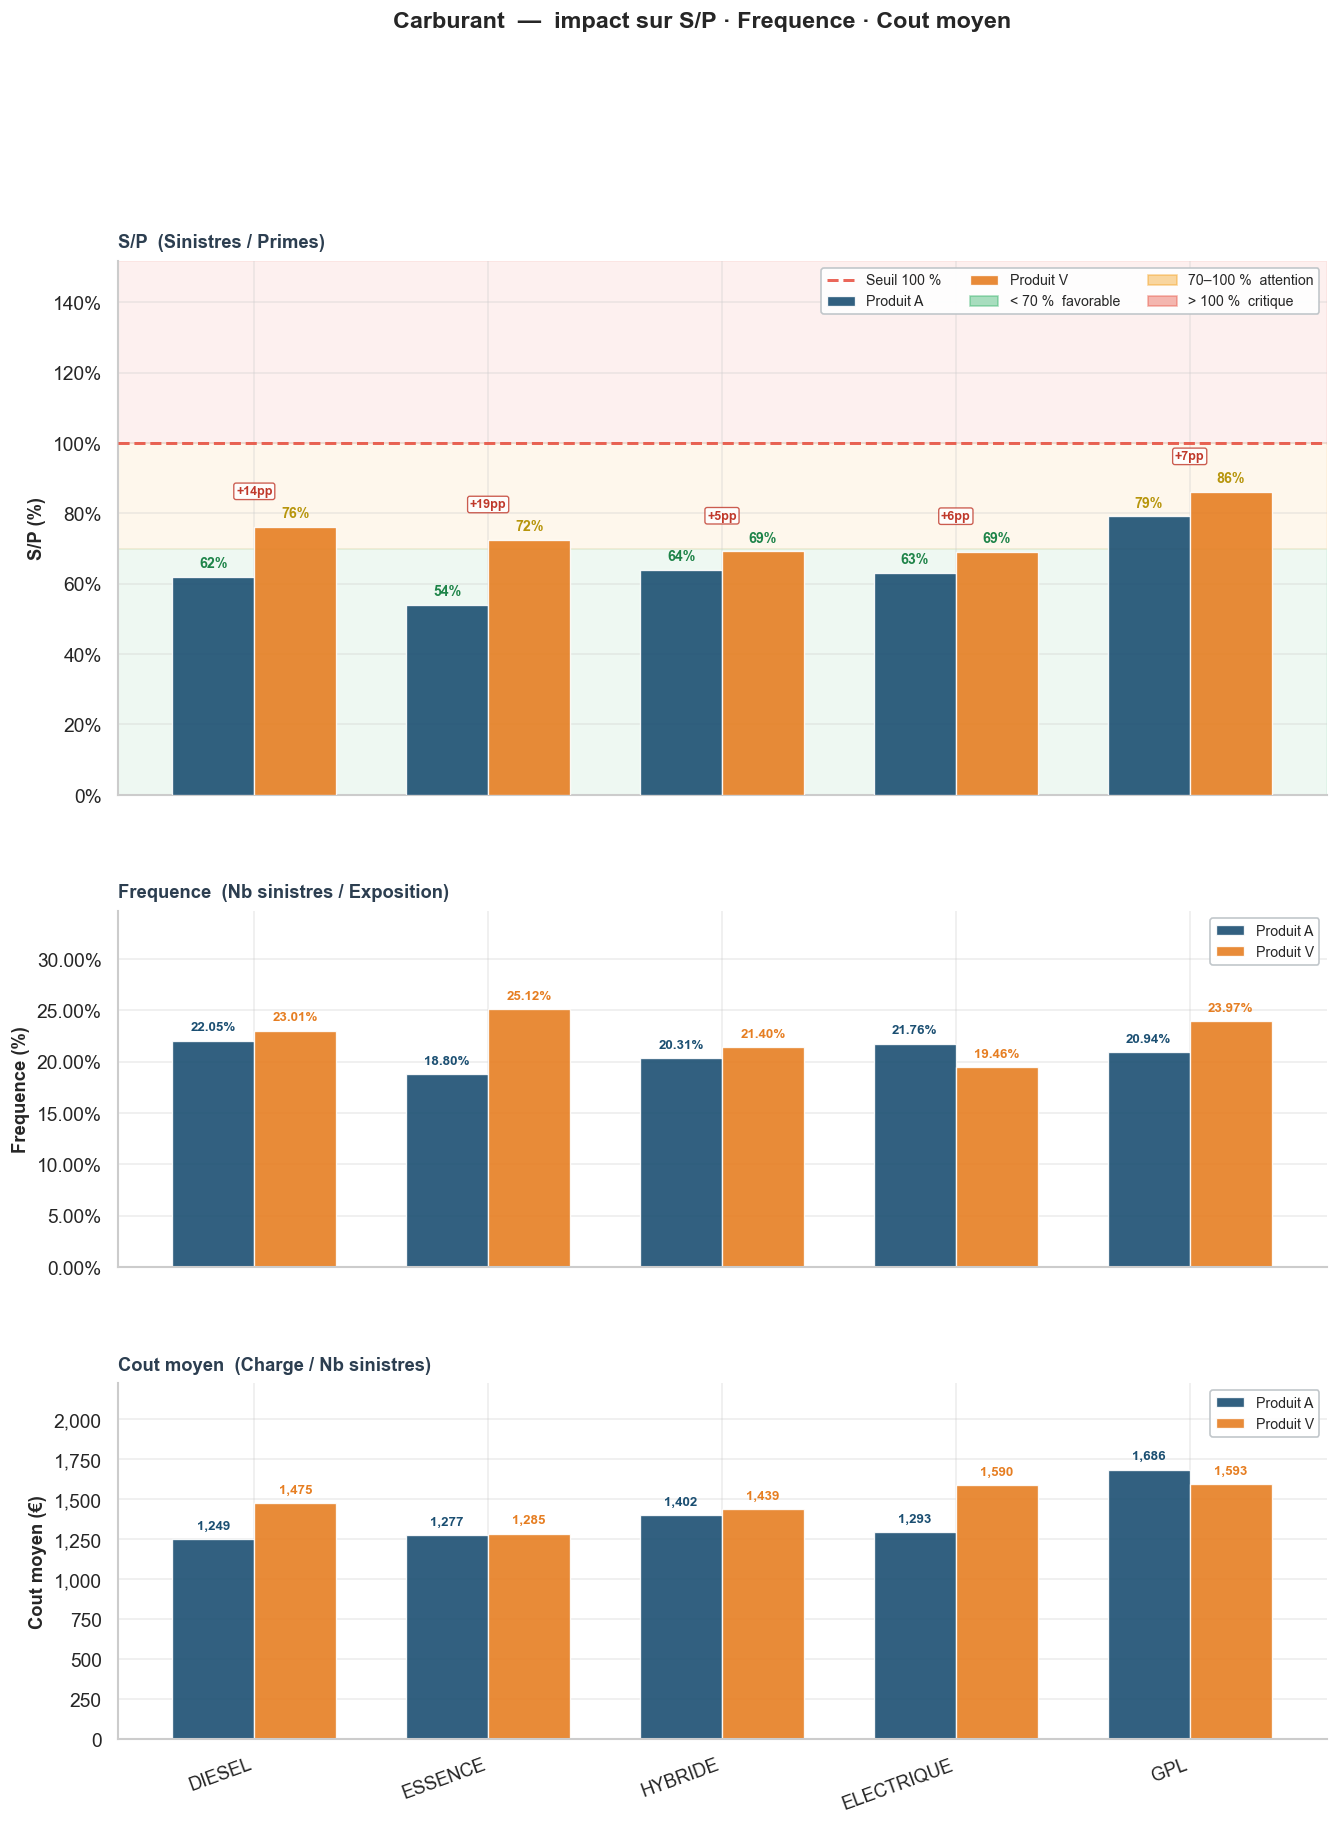

In [36]:
df_biv_carb = analyse_bivarie('carburant', CARB_ORDER, 'Carburant', 'bivarie_carburant.png')

### 6.2 Age conducteur x KPI

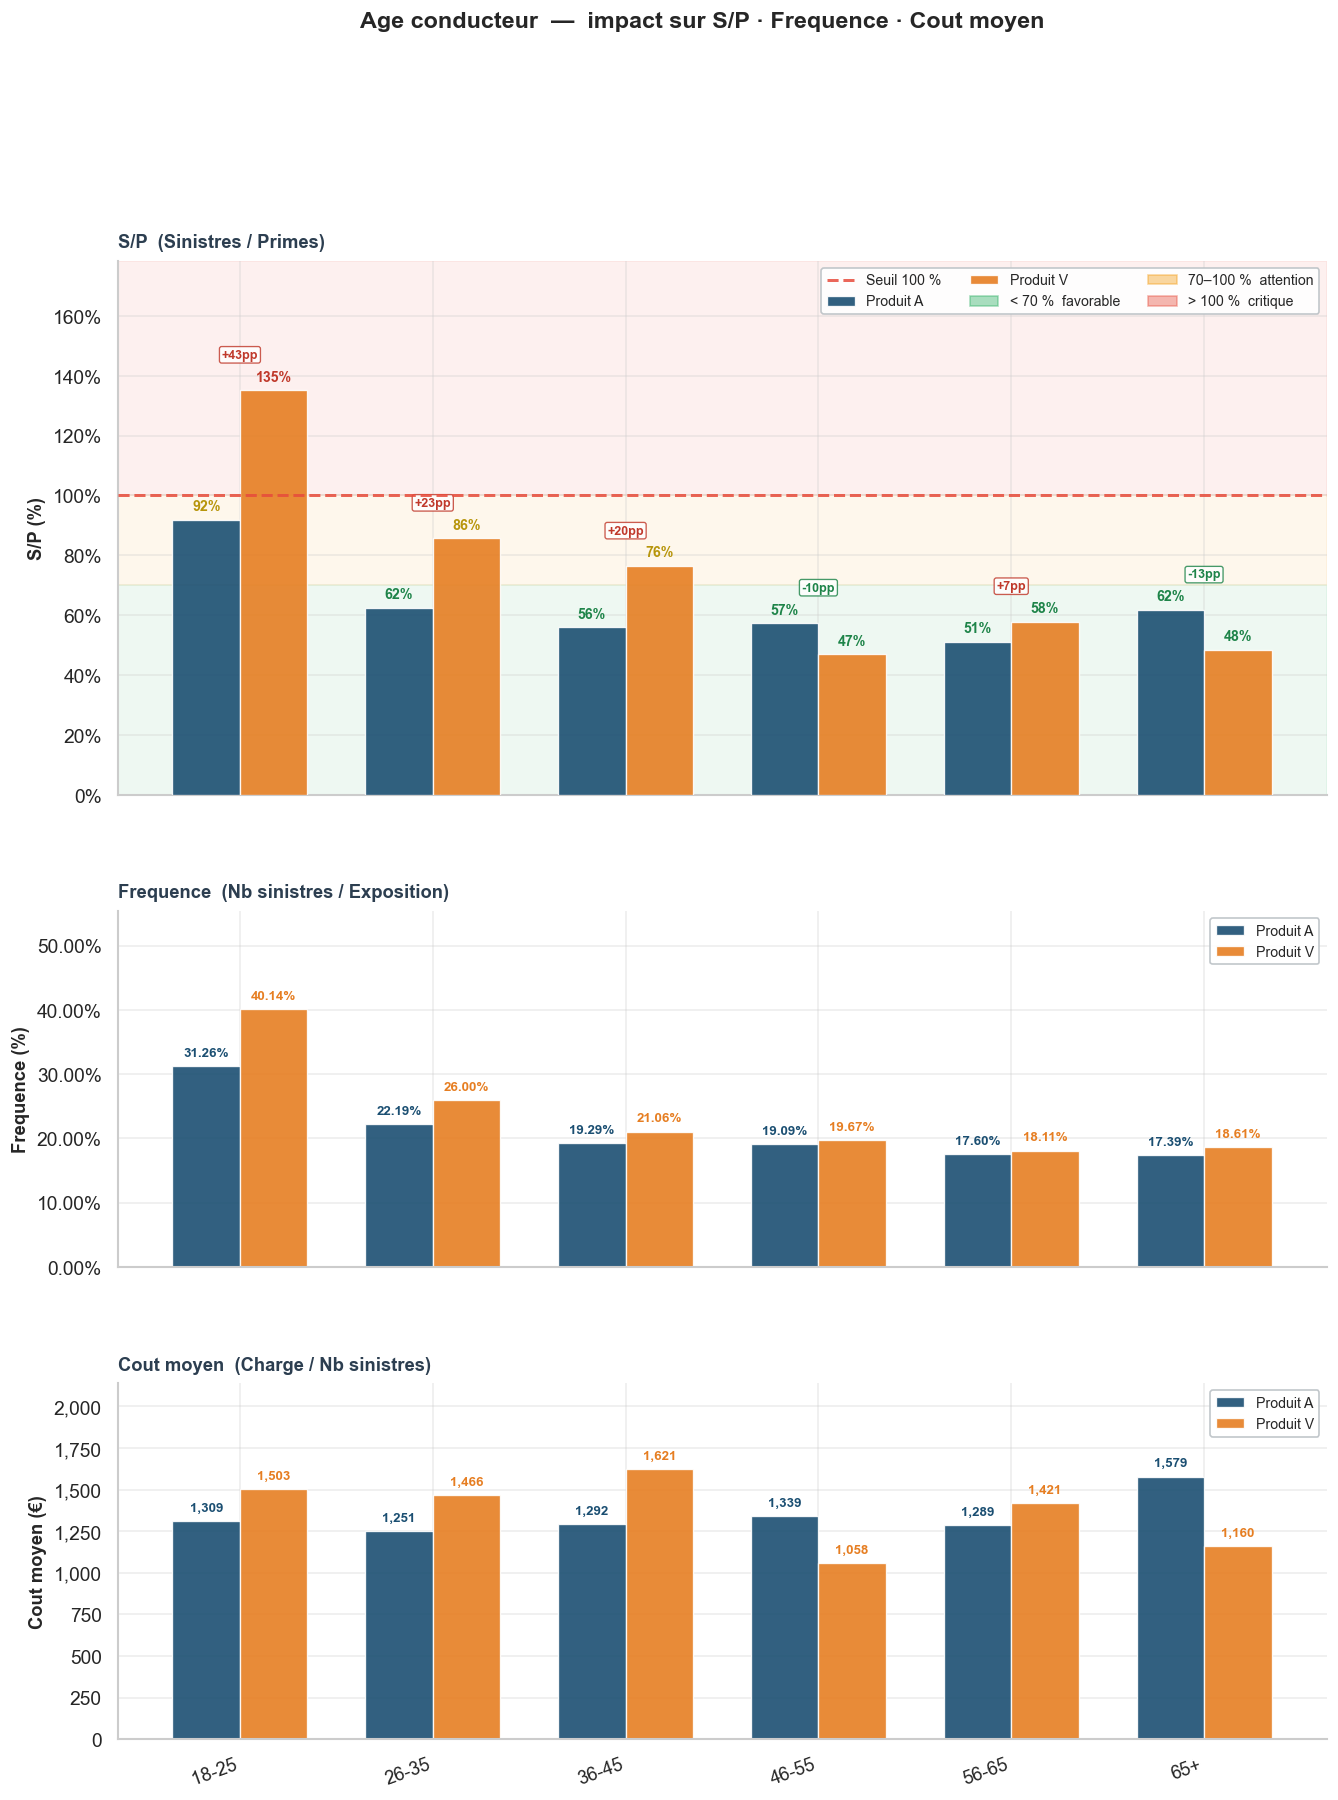

In [37]:
df_biv_age = analyse_bivarie('age_bin', AGE_ORDER, 'Age conducteur', 'bivarie_age.png')

### 6.3 Marque x KPI

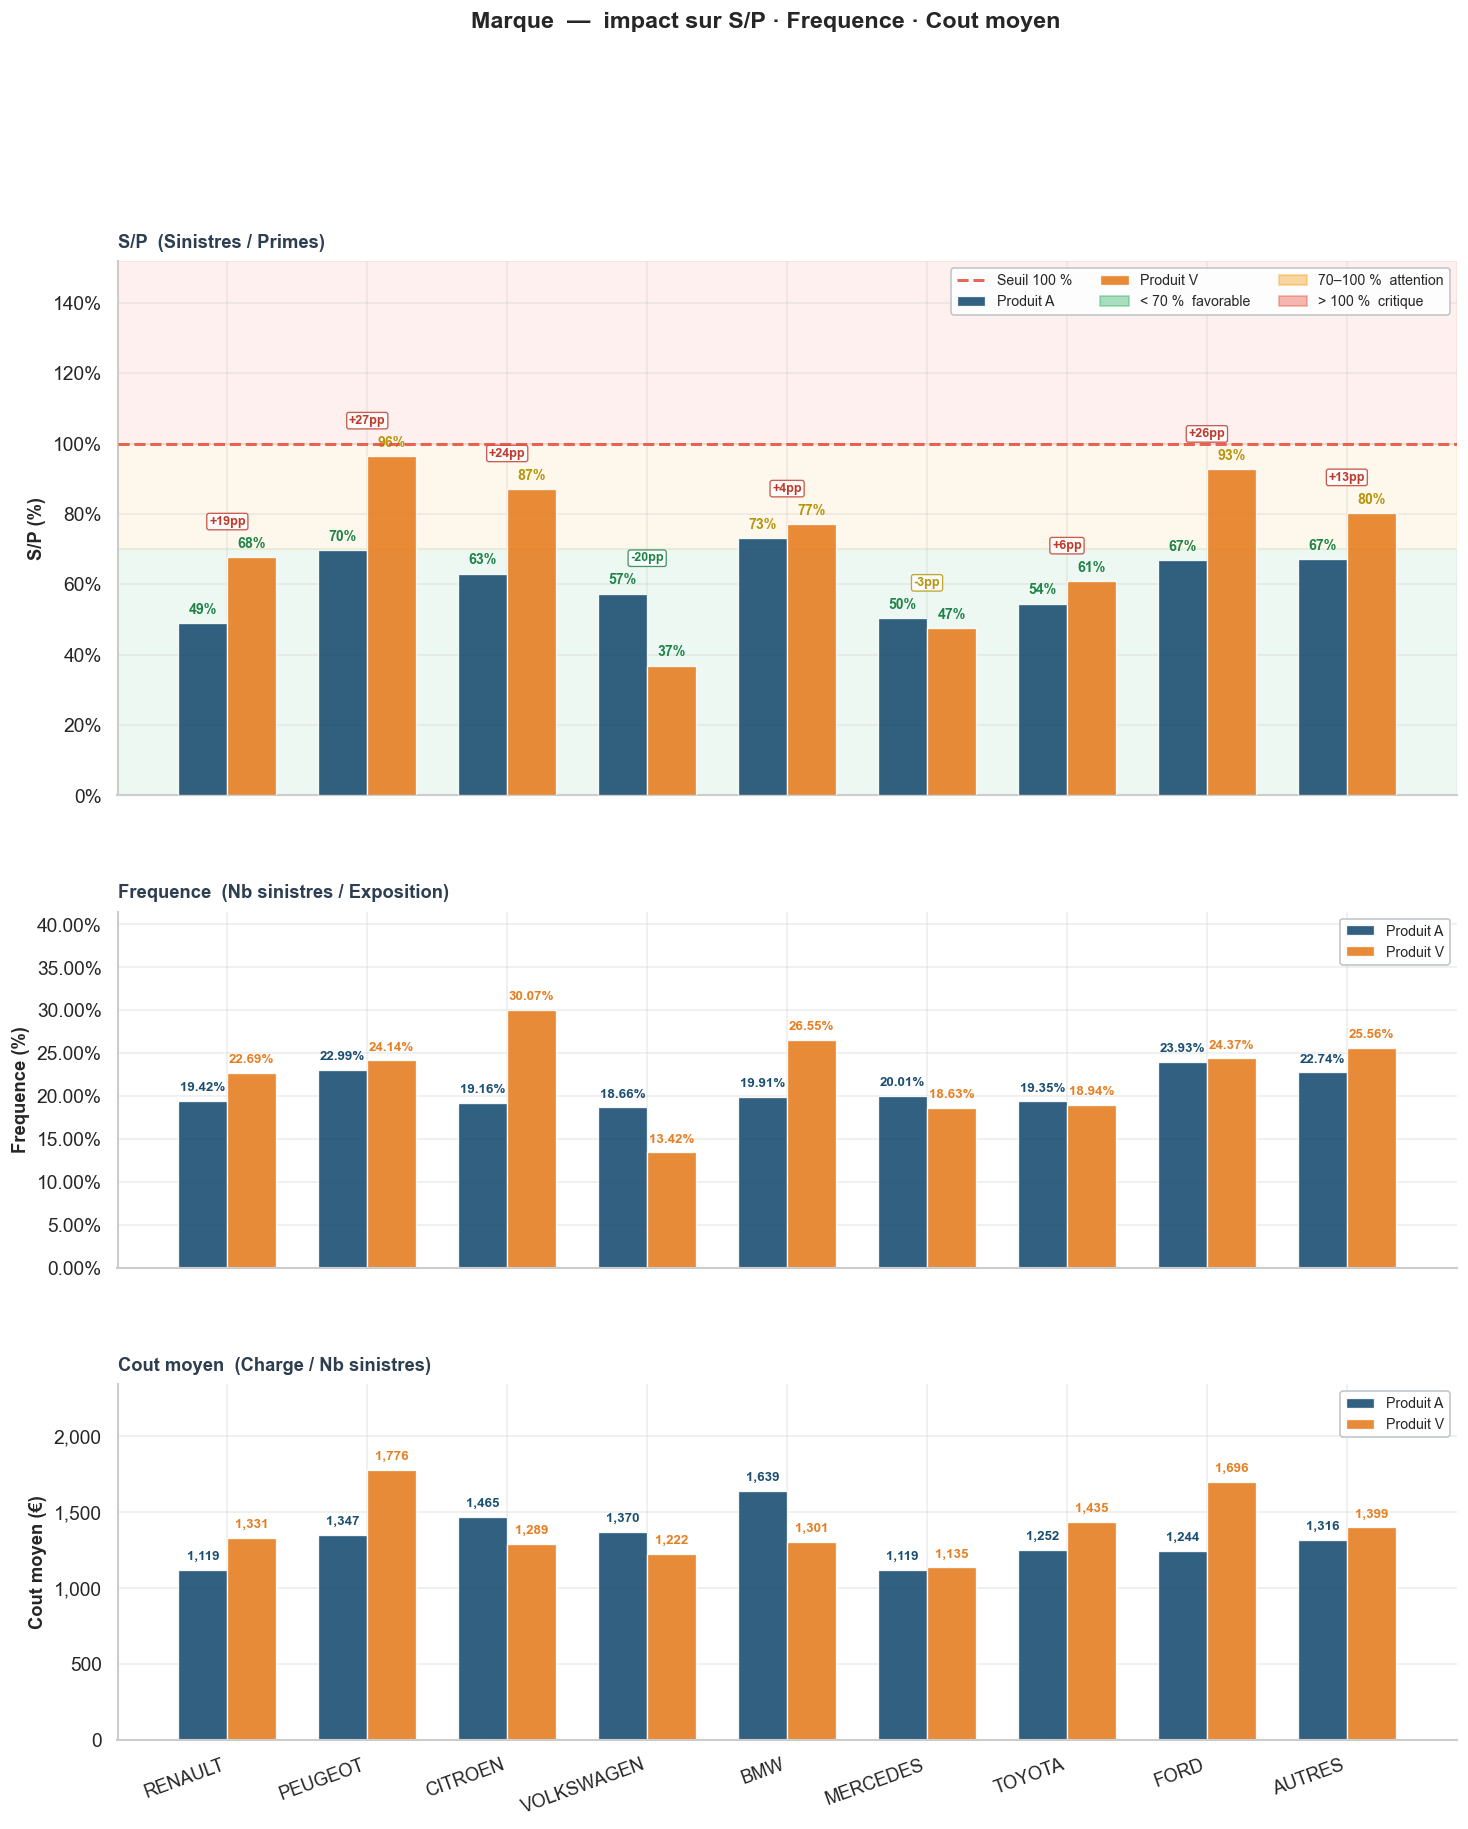

In [38]:
df_biv_marque = analyse_bivarie('marque', MARQ_ORDER, 'Marque', 'bivarie_marque.png')

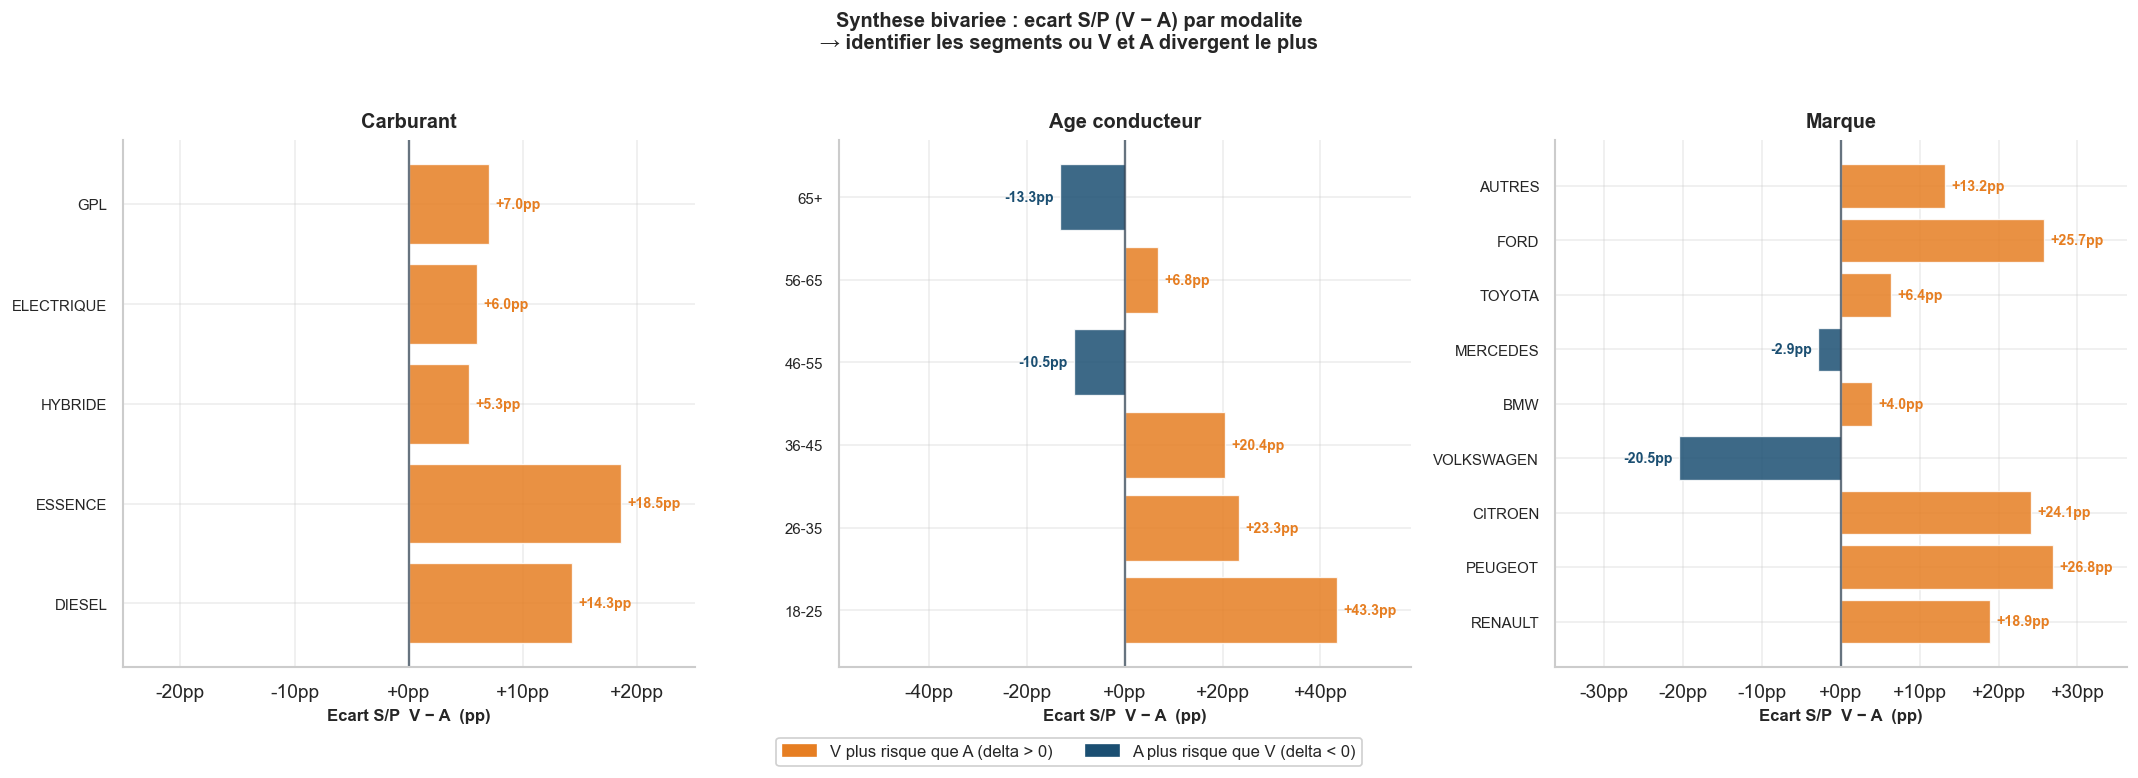

Synthese bivariee enregistree : synthese_lollipop_bivar.png


In [39]:

# ── Synthese bivariee : ecart S/P V − A par variable ─────────────────────────
# Un graphique "lollipop" qui resume pour chaque variable l'ecart de S/P V/A
# Lecture :
#   Barre positive (orange) → S/P de V > S/P de A pour cette modalite
#   Barre negative (bleue)  → S/P de V < S/P de A (V plus favorable)
#   Plus la barre est longue, plus la modalite discrimine les deux produits

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, (varname, df_biv, ordre) in zip(axes, [
    ('Carburant',     df_biv_carb,   CARB_ORDER),
    ('Age conducteur',df_biv_age,    AGE_ORDER),
    ('Marque',        df_biv_marque, MARQ_ORDER),
]):
    ordre_p = [m for m in ordre if m in df_biv['Modalite'].values]
    sv = df_biv.set_index('Modalite')

    deltas = []
    for modal in ordre_p:
        va = sv.loc[modal, 'S/P'] if (sv.index == modal).any() else np.nan
        # va is a series if both A and V exist
        if isinstance(va, pd.Series):
            d = (va.get('V', np.nan) - va.get('A', np.nan)) * 100 if hasattr(va, 'get') else np.nan
        else:
            d = np.nan
        deltas.append(d)

    # Recalcul propre
    deltas = []
    for modal in ordre_p:
        sp_a_m = df_biv[(df_biv['Produit'] == 'A') & (df_biv['Modalite'] == modal)]['S/P']
        sp_v_m = df_biv[(df_biv['Produit'] == 'V') & (df_biv['Modalite'] == modal)]['S/P']
        if len(sp_a_m) and len(sp_v_m):
            deltas.append((sp_v_m.values[0] - sp_a_m.values[0]) * 100)
        else:
            deltas.append(0.0)

    y   = np.arange(len(ordre_p))
    col = [COLOR_V if d >= 0 else COLOR_A for d in deltas]

    ax.barh(y, deltas, color=col, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.axvline(0, color='#2C3E50', lw=1.4, ls='-', alpha=0.7)

    for yi, d in zip(y, deltas):
        sign  = '+' if d >= 0 else ''
        xpos  = d + (max(abs(d) for d in deltas) * 0.03 if d >= 0 else -max(abs(d) for d in deltas) * 0.03)
        align = 'left' if d >= 0 else 'right'
        c     = COLOR_V if d >= 0 else COLOR_A
        ax.text(xpos, yi, f'{sign}{d:.1f}pp', va='center', ha=align,
                fontsize=8.5, fontweight='bold', color=c)

    ax.set_yticks(y)
    ax.set_yticklabels(ordre_p, fontsize=9)
    ax.set_xlabel('Ecart S/P  V − A  (pp)', fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}pp'))
    ax.set_title(varname, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlim(-max(abs(d) for d in deltas) * 1.35,
                 max(abs(d) for d in deltas) * 1.35)

# Legende commune
h = [mpatches.Patch(color=COLOR_V, label='V plus risque que A (delta > 0)'),
     mpatches.Patch(color=COLOR_A, label='A plus risque que V (delta < 0)')]
fig.legend(handles=h, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.92)

fig.suptitle('Synthese bivariee : ecart S/P (V − A) par modalite\n'
             '→ identifier les segments ou V et A divergent le plus',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('synthese_lollipop_bivar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Synthese bivariee enregistree : synthese_lollipop_bivar.png')


---
## 7. Export

In [40]:
with pd.ExcelWriter('KPI_AvsV_rapport.xlsx', engine='openpyxl') as writer:
    kpi_global.reset_index().to_excel(writer, sheet_name='KPI_Global',    index=False)
    kpi_gar.to_excel(writer, sheet_name='KPI_Garanties',  index=False)
    pd.concat([
        df_carb.assign(variable='carburant'),
        df_age.assign(variable='age_bin'),
        df_marque.assign(variable='marque'),
    ], ignore_index=True).to_excel(writer, sheet_name='Univarie', index=False)
    pd.concat([
        df_biv_carb.assign(variable='carburant'),
        df_biv_age.assign(variable='age_bin'),
        df_biv_marque.assign(variable='marque'),
    ], ignore_index=True).to_excel(writer, sheet_name='Bivarie', index=False)
    df_av.to_excel(writer, sheet_name='Donnees_harmonisees', index=False)

print('Rapport Excel exporte : KPI_AvsV_rapport.xlsx')
print()
print('Graphiques generes :')
for f in [
    'kpi_global.png',
    'kpi_garanties.png',
    'heatmap_sp_garantie.png',
    'univarie_carburant_distrib.png', 'univarie_carburant_kpi.png', 'univarie_carburant_scatter.png',
    'univarie_age_distrib.png',       'univarie_age_kpi.png',       'univarie_age_scatter.png',
    'univarie_marque_distrib.png',    'univarie_marque_kpi.png',    'univarie_marque_scatter.png',
    'synthese_bubble_univarie.png',
    'bivarie_carburant.png',
    'bivarie_age.png',
    'bivarie_marque.png',
    'synthese_lollipop_bivar.png',
]:
    print(f'  -> {f}')

Rapport Excel exporte : KPI_AvsV_rapport.xlsx

Graphiques generes :
  -> kpi_global.png
  -> kpi_garanties.png
  -> heatmap_sp_garantie.png
  -> univarie_carburant_distrib.png
  -> univarie_carburant_kpi.png
  -> univarie_carburant_scatter.png
  -> univarie_age_distrib.png
  -> univarie_age_kpi.png
  -> univarie_age_scatter.png
  -> univarie_marque_distrib.png
  -> univarie_marque_kpi.png
  -> univarie_marque_scatter.png
  -> synthese_bubble_univarie.png
  -> bivarie_carburant.png
  -> bivarie_age.png
  -> bivarie_marque.png
  -> synthese_lollipop_bivar.png
